## Condition Configuration

- `CONDITION`: condition name whose AI review outputs should be analyzed.
- `REUSE_REVIEW_EMBEDDINGS`: `True` to load cached review embeddings when the cache matches the current reviews.


In [ ]:
CONDITION = 'persona'
REUSE_REVIEW_EMBEDDINGS = True


# PART IV QUALITY — Compare Human and AI Reviews (Style-Controlled / Rephrased)

This notebook mirrors `compare_reviews.ipynb` but uses AI reviews generated on rephrased proposals.

**Review data:** `data/reviews/ai_reviews/ai_reviews_rephrased_*.json`
**Proposal data:** `data/*/rephrased/`

## 0) Environment setup (run once if needed)


In [20]:
# Uncomment if needed
# %pip install -q numpy pandas scipy matplotlib seaborn openpyxl textblob transformers torch scikit-learn statsmodels krippendorff


## 1) Imports, paths, and constants


In [ ]:
import json
import re
import itertools
import pickle
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, kruskal, wilcoxon, spearmanr, kendalltau, linregress
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob

import torch
from transformers import AutoTokenizer, AutoModel

sns.set_theme(style='whitegrid', context='talk')

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate.resolve()
    raise RuntimeError('Could not find project root containing src/ and data/.')

PROJECT_ROOT = find_project_root()

condition = CONDITION
AI_REVIEWS_PATH = sorted(
    (PROJECT_ROOT / 'data' / 'reviews' / 'ai_reviews' / condition / 'novelty').glob('novelty_reviews_*.json')
)[-1]
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'quality' / condition / 'novelty'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables' / 'quality' / condition / 'novelty'
REVIEW_EMBEDDINGS_FILE = PROJECT_ROOT / 'data' / 'embeddings' / 'reviews' / condition / 'novelty' / f'review_embeddings_{condition}.pkl'
OUTPUT_DIR = FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)

colors = {
    'Human': '#DC143C',
    'claude-opus-4-5': '#4A90E2',
    'gemini-3-pro-preview': '#7B68EE',
    'gpt-5.2': '#FF8C00',
}

CRITERIA_ORDER = [
    'new_question_topic_or_framing',
    'new_theory_concept_method_dataset_or_design',
    'unusual_combination_of_existing_ideas',
    'beyond_state_of_the_art',
    'credible_high_risk_high_gain',
    'unique_knowledge_generation',
]


## 2) Utility functions


In [22]:
def normalize_title(x: str) -> str:
    if pd.isna(x):
        return ''
    x = str(x).lower().strip()
    x = re.sub(r'[^a-z0-9]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def token_set_jaccard(a: str, b: str) -> float:
    sa = set(a.split())
    sb = set(b.split())
    if not sa and not sb:
        return 1.0
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)


def hybrid_similarity(a: str, b: str) -> float:
    seq = SequenceMatcher(None, a, b).ratio()
    jac = token_set_jaccard(a, b)
    return 0.7 * seq + 0.3 * jac


def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))


def interpret_cliffs_delta(delta):
    if np.isnan(delta):
        return 'NA'
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def benjamini_hochberg(pvalues):
    p = np.array(pvalues, dtype=float)
    n = len(p)
    if n == 0:
        return p
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out


def add_bh_fdr(df, p_col='p_value', group_cols=None, out_col='q_value'):
    df = df.copy()
    if group_cols is None:
        df[out_col] = benjamini_hochberg(df[p_col].values)
        return df
    df[out_col] = np.nan
    for _, idx in df.groupby(group_cols).groups.items():
        idx = list(idx)
        df.loc[idx, out_col] = benjamini_hochberg(df.loc[idx, p_col].values)
    return df


def mannwhitney_summary(a, b, metric_name='metric'):
    a = pd.Series(a).dropna().to_numpy()
    b = pd.Series(b).dropna().to_numpy()
    if len(a) == 0 or len(b) == 0:
        return {
            'metric': metric_name,
            'n_group1': len(a),
            'n_group2': len(b),
            'u_stat': np.nan,
            'p_value': np.nan,
            'cliffs_delta': np.nan,
            'delta_magnitude': 'NA',
        }
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    d = cliffs_delta(a, b)
    return {
        'metric': metric_name,
        'n_group1': len(a),
        'n_group2': len(b),
        'u_stat': u,
        'p_value': p,
        'cliffs_delta': d,
        'delta_magnitude': interpret_cliffs_delta(d),
    }


def sentiment_label(p):
    if p > 0.1:
        return 'positive'
    if p < -0.1:
        return 'negative'
    return 'neutral'


def sentiment_alignment(p1, p2):
    return 1 - (abs(p1 - p2) / 2)


def categorical_agreement(l1, l2):
    if l1 == l2:
        return 'agree'
    if {'positive', 'negative'} == {l1, l2}:
        return 'disagree'
    return 'partial'


def bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna().values, dtype=float)
    y = np.asarray(pd.Series(y).dropna().values, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan, np.nan
    diffs = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.mean(xb) - np.mean(yb))
    diffs = np.array(diffs)
    alpha = (1 - ci) / 2
    lo = np.quantile(diffs, alpha)
    hi = np.quantile(diffs, 1 - alpha)
    return np.mean(x) - np.mean(y), lo, hi


def permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna().values, dtype=float)
    y = np.asarray(pd.Series(y).dropna().values, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    obs = abs(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y]).copy()
    n_x = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:n_x]
        yp = pooled[n_x:]
        if abs(np.mean(xp) - np.mean(yp)) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def icc2_1_2k(ratings_matrix):
    # ICC(2,1) and ICC(2,k) for complete items x raters matrix
    X = np.asarray(ratings_matrix, dtype=float)
    if np.isnan(X).any():
        return np.nan, np.nan
    n, k = X.shape
    if n < 2 or k < 2:
        return np.nan, np.nan

    mean_row = X.mean(axis=1, keepdims=True)
    mean_col = X.mean(axis=0, keepdims=True)
    grand = X.mean()

    ss_row = k * np.sum((mean_row - grand) ** 2)
    ss_col = n * np.sum((mean_col - grand) ** 2)
    ss_err = np.sum((X - mean_row - mean_col + grand) ** 2)

    ms_row = ss_row / (n - 1)
    ms_col = ss_col / (k - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))

    icc21 = (ms_row - ms_err) / (ms_row + (k - 1) * ms_err + (k * (ms_col - ms_err) / n))
    icc2k = (ms_row - ms_err) / (ms_row + ((ms_col - ms_err) / n))
    return icc21, icc2k


def build_one_to_one_title_mapping(human_proposals, ai_proposals, fuzzy_threshold=0.70):
    h = human_proposals.copy().reset_index(drop=True)
    a = ai_proposals.copy().reset_index(drop=True)

    assigned_h = set()
    assigned_a = set()
    rows = []

    ai_by_norm = a.groupby('ai_title_norm')['ai_proposal_id'].apply(list).to_dict()
    for _, hr in h.iterrows():
        hp = hr['human_proposal_id']
        hn = hr['human_title_norm']
        candidates = ai_by_norm.get(hn, [])
        candidates = [x for x in candidates if x not in assigned_a]
        if len(candidates) == 1:
            ap = candidates[0]
            ar = a.loc[a['ai_proposal_id'] == ap].iloc[0]
            rows.append({
                'human_proposal_id': hp,
                'ai_proposal_id': ap,
                'human_title': hr['human_title'],
                'ai_title': ar['ai_title'],
                'human_title_norm': hn,
                'ai_title_norm': ar['ai_title_norm'],
                'similarity': 1.0,
                'match_method': 'exact',
            })
            assigned_h.add(hp)
            assigned_a.add(ap)

    h_un = h[~h['human_proposal_id'].isin(assigned_h)]
    a_un = a[~a['ai_proposal_id'].isin(assigned_a)]

    candidates = []
    for _, hr in h_un.iterrows():
        for _, ar in a_un.iterrows():
            sim = hybrid_similarity(hr['human_title_norm'], ar['ai_title_norm'])
            candidates.append((sim, hr['human_proposal_id'], ar['ai_proposal_id']))

    candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
    used_h = set()
    used_a = set()

    for sim, hp, ap in candidates:
        if sim < fuzzy_threshold:
            break
        if hp in used_h or ap in used_a:
            continue
        hr = h.loc[h['human_proposal_id'] == hp].iloc[0]
        ar = a.loc[a['ai_proposal_id'] == ap].iloc[0]
        rows.append({
            'human_proposal_id': hp,
            'ai_proposal_id': ap,
            'human_title': hr['human_title'],
            'ai_title': ar['ai_title'],
            'human_title_norm': hr['human_title_norm'],
            'ai_title_norm': ar['ai_title_norm'],
            'similarity': sim,
            'match_method': 'fuzzy',
        })
        used_h.add(hp)
        used_a.add(ap)

    mapping = pd.DataFrame(rows)

    h_unmatched = sorted(set(h['human_proposal_id']) - set(mapping['human_proposal_id']))
    a_unmatched = sorted(set(a['ai_proposal_id']) - set(mapping['ai_proposal_id']))

    diagnostics = {
        'n_human_proposals': int(h.shape[0]),
        'n_ai_proposals': int(a.shape[0]),
        'n_matched': int(mapping.shape[0]),
        'n_exact': int((mapping['match_method'] == 'exact').sum()) if not mapping.empty else 0,
        'n_fuzzy': int((mapping['match_method'] == 'fuzzy').sum()) if not mapping.empty else 0,
        'n_unmatched_human': int(len(h_unmatched)),
        'n_unmatched_ai': int(len(a_unmatched)),
    }

    return mapping, diagnostics, h_unmatched, a_unmatched


## 3) Load and flatten AI reviews


In [23]:
with open(AI_REVIEWS_PATH, 'r') as f:
    ai_payload = json.load(f)

rows = []
for r in ai_payload.get('reviews', []):
    # Novelty format: evaluations is a flat dict with criteria at top level
    ev = r.get('evaluations') or {}
    if not isinstance(ev, dict):
        continue

    criteria = {k: np.nan for k in CRITERIA_ORDER}
    for c in CRITERIA_ORDER:
        dim = ev.get(c)
        criteria[c] = dim.get('score', np.nan) if isinstance(dim, dict) else np.nan

    overall_score = ev.get('overall_novelty_score', np.nan)
    overall_summary = ev.get('overall_summary', '') or ''
    review_text = overall_summary

    row = {
        'proposal_id': r.get('proposal_id') or ev.get('proposal_id'),
        'title': r.get('title'),
        'title_norm': normalize_title(r.get('title', '')),
        'author': r.get('author'),
        'evaluator': r.get('evaluator'),
        'overall_score': overall_score,
        'review_text': review_text,
    }
    row.update(criteria)
    rows.append(row)

ai_df = pd.DataFrame(rows)

# Many AI reviews have proposal_id set to placeholders like 'N/A' or 'None'.
# Treat those as missing, then fall back to title_norm (stable per proposal).
_pid = ai_df['proposal_id']
_pid_str = _pid.astype(str).str.strip().str.lower()
placeholder = _pid.isna() | _pid_str.isin({'', 'n/a', 'na', 'none', 'nan'})
ai_df.loc[placeholder, 'proposal_id'] = np.nan
ai_df['proposal_id'] = ai_df['proposal_id'].fillna(ai_df['title_norm'])

# Now build a stable proposal UID (author + proposal_id)
ai_df['proposal_uid'] = ai_df['author'].astype(str) + '::' + ai_df['proposal_id'].astype(str)

for c in ['overall_score'] + CRITERIA_ORDER:
    ai_df[c] = pd.to_numeric(ai_df[c], errors='coerce')

print("Unique proposals per author (nunique proposal_uid):")
print(ai_df.groupby('author')['proposal_uid'].nunique().sort_values(ascending=False))

print("\nReviews per author (rows):")
print(ai_df.groupby('author').size().sort_values(ascending=False))

print('AI reviews rows:', len(ai_df))
print('Authors:', sorted(ai_df['author'].dropna().unique()))
print('Evaluators:', sorted(ai_df['evaluator'].dropna().unique()))
ai_df.head(3)


Unique proposals per author (nunique proposal_uid):
author
claude-opus-4-5         23
gemini-3-pro-preview    23
gpt-5.2                 23
human-y1                12
human-y2                12
Name: proposal_uid, dtype: int64

Reviews per author (rows):
author
claude-opus-4-5         69
gemini-3-pro-preview    69
gpt-5.2                 69
human-y1                36
human-y2                33
dtype: int64
AI reviews rows: 276
Authors: ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2', 'human-y1', 'human-y2']
Evaluators: ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']


,proposal_id,title,title_norm,author,evaluator,overall_score,review_text,new_question_topic_or_framing,new_theory_concept_method_dataset_or_design,unusual_combination_of_existing_ideas,beyond_state_of_the_art,credible_high_risk_high_gain,unique_knowledge_generation,proposal_uid
0,a cross modal synthesis of biomolecular conden...,A Cross-Modal Synthesis of Biomolecular Conden...,a cross modal synthesis of biomolecular conden...,gpt-5.2,gpt-5.2,4.0,The proposal makes a strong case for novelty p...,4.0,3.0,5.0,4.0,4.0,4.0,gpt-5.2::a cross modal synthesis of biomolecul...
1,a cross modal synthesis of biomolecular conden...,A Cross-Modal Synthesis of Biomolecular Conden...,a cross modal synthesis of biomolecular conden...,gpt-5.2,gemini-3-pro-preview,4.5,"The proposal presents a highly ambitious, cros...",4.0,4.0,5.0,5.0,4.0,5.0,gpt-5.2::a cross modal synthesis of biomolecul...
2,a cross modal synthesis of biomolecular conden...,A Cross-Modal Synthesis of Biomolecular Conden...,a cross modal synthesis of biomolecular conden...,gpt-5.2,claude-opus-4-5,4.0,This proposal presents a highly novel synthesi...,4.0,4.0,5.0,4.0,4.0,4.0,gpt-5.2::a cross modal synthesis of biomolecul...


# R2: How are AI proposals' quality compare to humans (evaluated by AI)

## 10) Proposal-quality analysis dataset (proposal-level means, no duplicated human-all rows)

**Purpose**
Create the main proposal-level scoring dataset for quality comparisons.

**How this is done**
- Average scores across evaluators within each proposal.
- Keep true base groups (`human-y1`, `human-y2`, and each AI author model).
- Construct `human-all` only analytically (not by duplicating rows in source data).

**Why this method is appropriate**
- Proposal-level summaries align with the research question: proposal quality, not individual review idiosyncrasy.
- Avoiding duplicated rows prevents biased evaluator-level analyses and inflated sample counts.


In [24]:
# Purpose:
# Build proposal-level quality dataset and summary stats without contaminating source
# data via duplicated synthetic groups.

QUALITY_METRICS = ['overall_score'] + CRITERIA_ORDER

proposal_scores = (
    ai_df.groupby(['author', 'proposal_id', 'proposal_uid'])[QUALITY_METRICS]
    .mean()
    .reset_index()
)

base_groups = ['human-y1', 'human-y2', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
proposal_scores = proposal_scores[proposal_scores['author'].isin(base_groups)].copy()


def get_group_values(df_, group_name, metric):
    if group_name == 'human-all':
        return df_[df_['author'].isin(['human-y1', 'human-y2'])][metric].dropna().values
    return df_[df_['author'] == group_name][metric].dropna().values


keep_groups = ['human-y1', 'human-y2', 'human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

summary_rows = []
for g in keep_groups:
    vals = proposal_scores[proposal_scores['author'].isin(['human-y1', 'human-y2'])]['overall_score'] if g == 'human-all' else proposal_scores[proposal_scores['author'] == g]['overall_score']
    summary_rows.append({
        'group': g,
        'n_proposals': int(vals.notna().sum()),
        'overall_mean': float(vals.mean()),
        'overall_median': float(vals.median()),
        'overall_std': float(vals.std()),
    })

summary_overall_df = pd.DataFrame(summary_rows)
summary_overall_df


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.644444,3.700000,0.261052
1,human-y2,11,3.895455,3.900000,0.210830
2,human-all,23,3.764493,3.766667,0.265922
3,claude-opus-4-5,23,3.402899,3.500000,0.352325
4,gemini-3-pro-preview,23,3.656522,3.733333,0.301249
5,gpt-5.2,23,3.993478,4.033333,0.236757


### Interpretation: Proposal-Level Summary Dataset

- Check `n_proposals` per group first; unequal group sizes affect power.
- `overall_mean`/`median` provide central tendency; `overall_std` indicates heterogeneity.
- Use this table to contextualize later pairwise tests (e.g., large variance can weaken significance despite mean gaps).


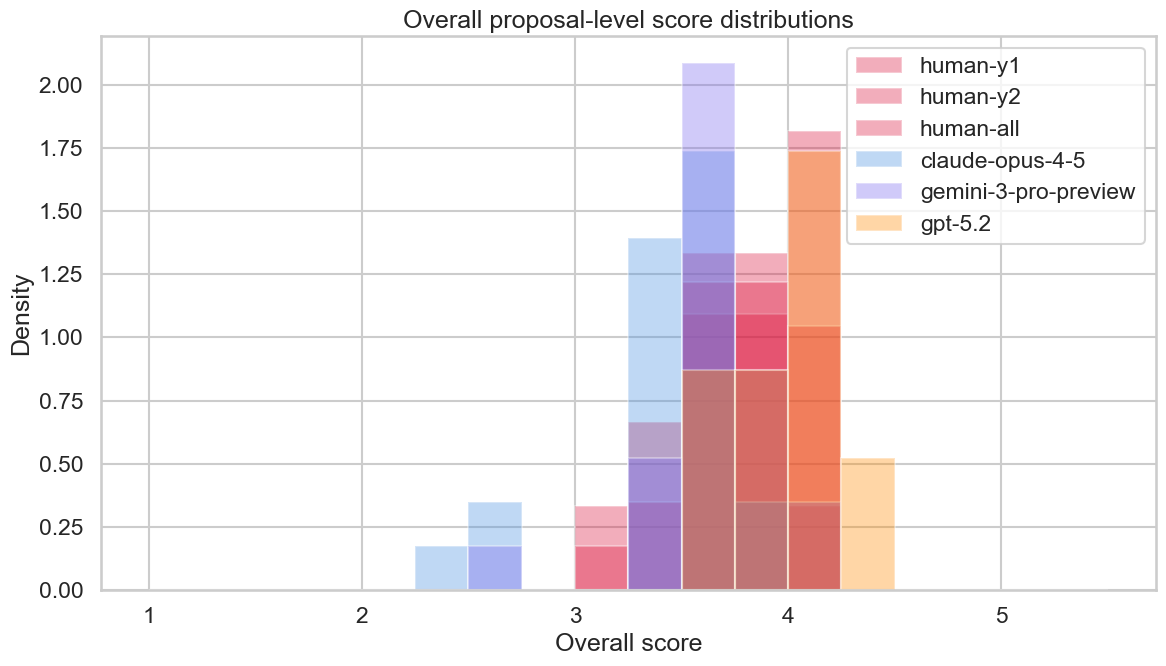

/var/folders/v9/9n8npksj53380_v63d_r9jm80000gn/T/ipykernel_47768/2691599293.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, palette=palette)


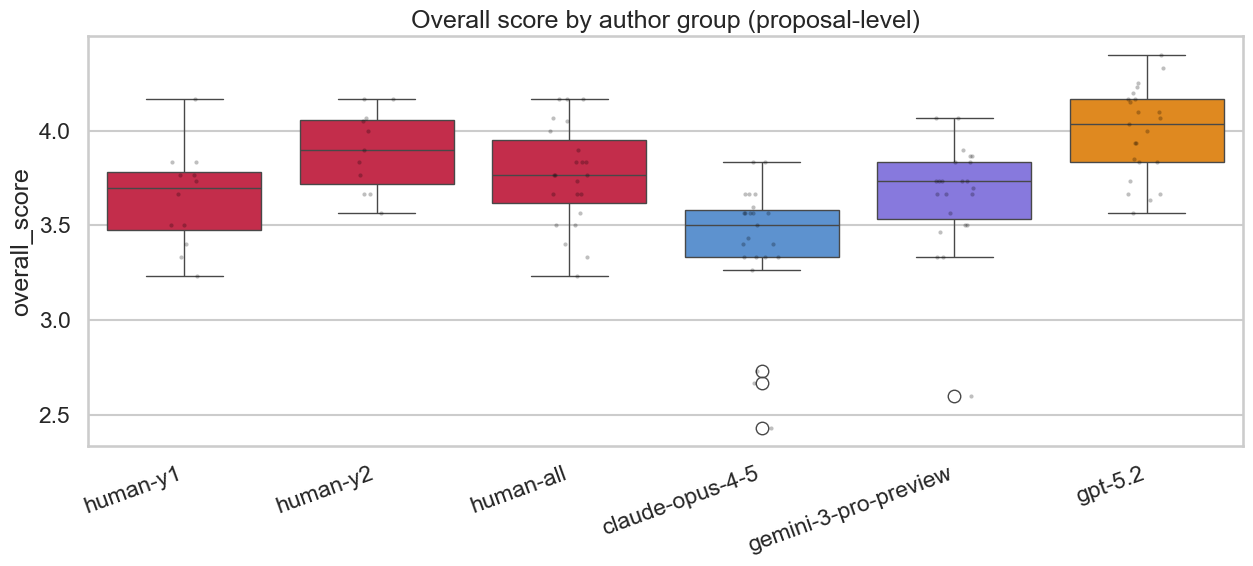

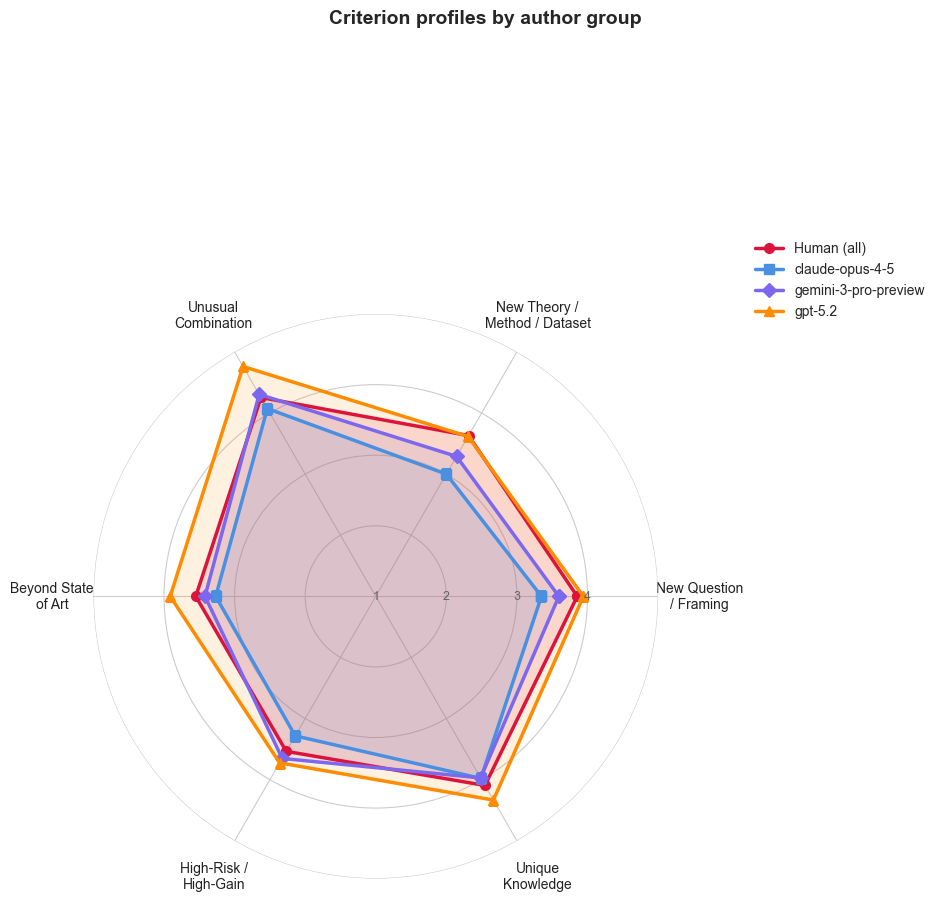

In [25]:
# Purpose:
# Visual diagnostics for quality distributions and criterion profiles.
#
# Note:
# 'human-all' is generated only for comparative plotting convenience.

plot_frames = []
for g in keep_groups:
    if g == 'human-all':
        tmp = proposal_scores[proposal_scores['author'].isin(['human-y1', 'human-y2'])].copy()
    else:
        tmp = proposal_scores[proposal_scores['author'] == g].copy()
    tmp['author_group'] = g
    plot_frames.append(tmp)
plot_df = pd.concat(plot_frames, ignore_index=True)

plt.figure(figsize=(12, 7))
for g in keep_groups:
    s = plot_df.loc[plot_df['author_group'] == g, 'overall_score'].dropna()
    if len(s) == 0:
        continue
    color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
    plt.hist(s, bins=np.arange(1, 5.6, 0.25), alpha=0.35, label=g, color=color, density=True)
plt.xlabel('Overall score')
plt.ylabel('Density')
plt.title('Overall proposal-level score distributions')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_overall_histograms_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(13, 6))
palette = {g: (colors['Human'] if 'human' in g else colors.get(g, '#999999')) for g in keep_groups}
sns.boxplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, palette=palette)
sns.stripplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, color='black', alpha=0.25, size=3)
plt.xticks(rotation=20, ha='right')
plt.title('Overall score by author group (proposal-level)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_overall_boxplot_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

radar_groups = ['human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# Short display labels matching the reference style
radar_labels = {
    'new_question_topic_or_framing':               'New Question\n/ Framing',
    'new_theory_concept_method_dataset_or_design': 'New Theory /\nMethod / Dataset',
    'unusual_combination_of_existing_ideas':       'Unusual\nCombination',
    'beyond_state_of_the_art':                     'Beyond State\nof Art',
    'credible_high_risk_high_gain':                'High-Risk /\nHigh-Gain',
    'unique_knowledge_generation':                 'Unique\nKnowledge',
}

# Marker styles per group
radar_markers = {
    'human-all':           'o',
    'claude-opus-4-5':     's',
    'gemini-3-pro-preview':'D',
    'gpt-5.2':             '^',
}

radar_legend_names = {
    'human-all':           'Human (all)',
    'claude-opus-4-5':     'claude-opus-4-5',
    'gemini-3-pro-preview':'gemini-3-pro-preview',
    'gpt-5.2':             'gpt-5.2',
}

N = len(CRITERIA_ORDER)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(10, 10), facecolor='white')
ax = fig.add_subplot(111, polar=True, facecolor='white')

# Light gray gridlines only, no outer spine
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels([])
ax.yaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='-')
ax.xaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='-')
ax.spines['polar'].set_visible(False)

# Scale numbers 1-4 along the first spoke (rightward horizontal)
for tick_val in [1, 2, 3, 4]:
    ax.text(angles[0], tick_val, str(tick_val),
            ha='center', va='center', fontsize=9, color='#666666')

# Plot each group
for g in radar_groups:
    vals = [np.nanmean(get_group_values(proposal_scores, g, c)) for c in CRITERIA_ORDER]
    vals += vals[:1]
    color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
    marker = radar_markers.get(g, 'o')
    ax.plot(angles, vals, linewidth=2.5, color=color,
            marker=marker, markersize=7, markerfacecolor=color,
            label=radar_legend_names.get(g, g))
    ax.fill(angles, vals, alpha=0.12, color=color)

# Axis spoke labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [radar_labels.get(c, c) for c in CRITERIA_ORDER],
    fontsize=10, color='#222222'
)
ax.tick_params(pad=14)

# Legend outside the chart
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.15), frameon=False, fontsize=10)

fig.suptitle('Criterion profiles by author group', fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_radar_criteria_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()


### Interpretation: Quality Distribution Plots

- Histogram/boxplot: inspect central location, spread, and skew across groups.
- Radar chart: identify criteria where human vs AI profiles diverge most.
- Prefer combining visual patterns with statistical tables from Sections 11-12 before drawing conclusions.


## 11) Pairwise quality tests (MW + Cliff's delta + FDR) on proposal-level means

**Purpose**
Identify where quality differences exist between proposal source groups (human cohorts vs AI models), overall and by criterion.

**How this is done**
- Run all pairwise group comparisons for each metric.
- Report Mann-Whitney U, p-value, Cliff's delta, and group means.
- Apply FDR correction within each metric.

**Why this method is appropriate**
- Non-parametric tests are suitable for small and potentially skewed distributions.
- Effect sizes (Cliff's delta) provide magnitude and direction beyond p-values.


In [26]:
# Purpose:
# Pairwise group comparisons for each quality metric, with FDR control.
#
# Two separate comparisons:
#   1. human-y1 vs human-y2  — are the two human cohorts different?
#      Uses base_groups combinations (no human-all, avoids subset/superset overlap).
#   2. human-all vs each AI group — human-vs-AI contrast at full power (n≈23 vs n≈12).
#      human-all is independent of the AI groups, so Mann-Whitney is valid here.

ai_groups = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# --- 1) Human cohort comparison: y1 vs y2 ---
cohort_results = []
for metric in QUALITY_METRICS:
    s1 = get_group_values(proposal_scores, 'human-y1', metric)
    s2 = get_group_values(proposal_scores, 'human-y2', metric)
    out = mannwhitney_summary(s1, s2, metric_name=metric)
    out['group1'] = 'human-y1'
    out['group2'] = 'human-y2'
    out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
    out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
    cohort_results.append(out)

human_cohort_df = pd.DataFrame(cohort_results)
human_cohort_df = add_bh_fdr(human_cohort_df, p_col='p_value', group_cols=['metric'])

# --- 2) Human-all vs each AI group ---
vs_ai_results = []
for metric in QUALITY_METRICS:
    s_human = get_group_values(proposal_scores, 'human-all', metric)
    for g in ai_groups:
        s_ai = get_group_values(proposal_scores, g, metric)
        out = mannwhitney_summary(s_human, s_ai, metric_name=metric)
        out['group1'] = 'human-all'
        out['group2'] = g
        out['mean_group1'] = np.mean(s_human) if len(s_human) else np.nan
        out['mean_group2'] = np.mean(s_ai) if len(s_ai) else np.nan
        vs_ai_results.append(out)

vs_ai_df = pd.DataFrame(vs_ai_results)
vs_ai_df = add_bh_fdr(vs_ai_df, p_col='p_value', group_cols=['metric'])

# Also keep a full pairwise table (base_groups only, for AI-vs-AI and other pairs)
pairwise_results = []
for metric in QUALITY_METRICS:
    for g1, g2 in itertools.combinations(base_groups, 2):
        s1 = get_group_values(proposal_scores, g1, metric)
        s2 = get_group_values(proposal_scores, g2, metric)
        out = mannwhitney_summary(s1, s2, metric_name=metric)
        out['group1'] = g1
        out['group2'] = g2
        out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
        out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
        pairwise_results.append(out)

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df = add_bh_fdr(pairwise_df, p_col='p_value', group_cols=['metric'])

print('1) Human cohort comparison (y1 vs y2):')
display(human_cohort_df.sort_values(['metric', 'q_value']))
print('2) Human-all vs each AI group:')
display(vs_ai_df.sort_values(['metric', 'q_value', 'p_value']))


1) Human cohort comparison (y1 vs y2):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
4,beyond_state_of_the_art,12,11,50.5,0.337217,-0.234848,small,human-y1,human-y2,3.472222,3.636364,0.337217
5,credible_high_risk_high_gain,12,11,58.5,0.623286,-0.113636,negligible,human-y1,human-y2,3.472222,3.606061,0.623286
1,new_question_topic_or_framing,12,11,41.5,0.124564,-0.371212,medium,human-y1,human-y2,3.666667,4.060606,0.124564
2,new_theory_concept_method_dataset_or_design,12,11,39.5,0.082412,-0.401515,medium,human-y1,human-y2,3.472222,3.803030,0.082412
0,overall_score,12,11,31.0,0.032982,-0.530303,large,human-y1,human-y2,3.644444,3.895455,0.032982
6,unique_knowledge_generation,12,11,36.0,0.038634,-0.454545,medium,human-y1,human-y2,3.916667,4.287879,0.038634
3,unusual_combination_of_existing_ideas,12,11,58.0,0.627173,-0.121212,negligible,human-y1,human-y2,4.222222,4.287879,0.627173


2) Human-all vs each AI group:


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
14,beyond_state_of_the_art,23,23,134.0,0.003346,-0.493384,large,human-all,gpt-5.2,3.550725,3.913043,0.010038
12,beyond_state_of_the_art,23,23,363.5,0.024038,0.374291,medium,human-all,claude-opus-4-5,3.550725,3.268116,0.036056
13,beyond_state_of_the_art,23,23,311.0,0.287629,0.175803,small,human-all,gemini-3-pro-preview,3.550725,3.420290,0.287629
17,credible_high_risk_high_gain,23,23,171.0,0.015808,-0.353497,medium,human-all,gpt-5.2,3.536232,3.724638,0.047424
15,credible_high_risk_high_gain,23,23,347.5,0.051647,0.313800,small,human-all,claude-opus-4-5,3.536232,3.282609,0.077471
16,credible_high_risk_high_gain,23,23,217.0,0.180293,-0.179584,small,human-all,gemini-3-pro-preview,3.536232,3.652174,0.180293
3,new_question_topic_or_framing,23,23,418.0,0.000594,0.580340,large,human-all,claude-opus-4-5,3.855072,3.347826,0.001781
4,new_question_topic_or_framing,23,23,354.0,0.044793,0.338374,medium,human-all,gemini-3-pro-preview,3.855072,3.594203,0.067190
5,new_question_topic_or_framing,23,23,252.0,0.785365,-0.047259,negligible,human-all,gpt-5.2,3.855072,3.942029,0.785365
6,new_theory_concept_method_dataset_or_design,23,23,433.5,0.000118,0.638941,large,human-all,claude-opus-4-5,3.630435,3.000000,0.000353


### Interpretation: Pairwise Quality Tests

- For each metric, prioritize `q_value` (FDR-adjusted) over raw `p_value`.
- Report both **statistical evidence** (`q_value`) and **practical effect** (`cliffs_delta`, `delta_magnitude`).
- In `vs_human_all`, positive vs negative delta tells whether the comparator tends to score above or below `human-all`.


## 11b) Effect size & significance visualization


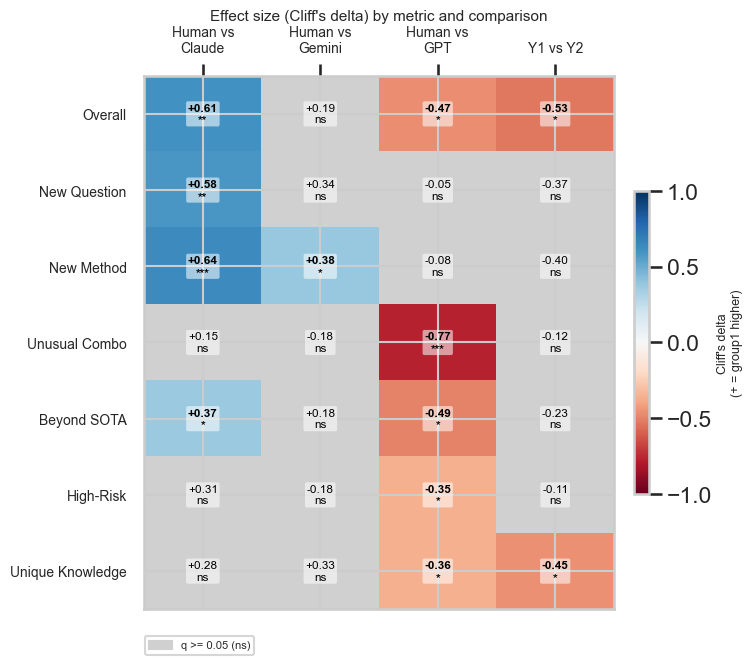

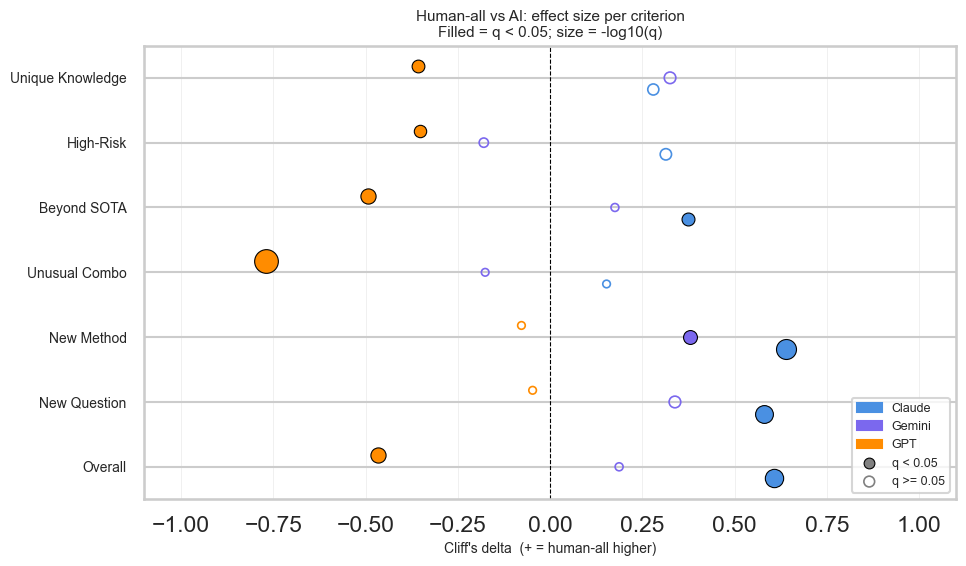

In [27]:
# Panel 1: Effect-size heatmap
#   rows = metrics, columns = comparisons
#   color = Cliff's delta; gray = not significant (q >= 0.05)
#
# Panel 2: Dot plot (human-all vs AI only)
#   x = Cliff's delta, y = metric, color = AI model
#   filled = significant (q < 0.05), hollow = not significant
#   dot size = -log10(q_value)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

metric_labels = {
    'overall_score':                               'Overall',
    'new_question_topic_or_framing':               'New Question',
    'new_theory_concept_method_dataset_or_design': 'New Method',
    'unusual_combination_of_existing_ideas':       'Unusual Combo',
    'beyond_state_of_the_art':                     'Beyond SOTA',
    'credible_high_risk_high_gain':                'High-Risk',
    'unique_knowledge_generation':                 'Unique Knowledge',
}
row_order = ['overall_score'] + CRITERIA_ORDER

plot_stats = pd.concat([vs_ai_df, human_cohort_df], ignore_index=True)
col_order  = [
    'human-all vs claude-opus-4-5',
    'human-all vs gemini-3-pro-preview',
    'human-all vs gpt-5.2',
    'human-y1 vs human-y2',
]
plot_stats['col_label'] = plot_stats['group1'] + ' vs ' + plot_stats['group2']

delta_pivot = plot_stats.pivot(index='metric', columns='col_label', values='cliffs_delta').reindex(index=row_order, columns=col_order)
q_pivot     = plot_stats.pivot(index='metric', columns='col_label', values='q_value').reindex(index=row_order, columns=col_order)

readable_rows = [metric_labels.get(m, m) for m in row_order]
readable_cols = ['Human vs\nClaude', 'Human vs\nGemini', 'Human vs\nGPT', 'Y1 vs Y2']

# --- Panel 1: Heatmap ---
fig, ax = plt.subplots(figsize=(8, 7))

delta_arr = delta_pivot.values.astype(float)
q_arr     = q_pivot.values.astype(float)

# Single colormap pass: NaN (non-significant) renders as gray via set_bad()
cmap_hm = plt.cm.RdBu.copy()
cmap_hm.set_bad(color='#d0d0d0')
norm   = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
masked = np.where(q_arr >= 0.05, np.nan, delta_arr)

im = ax.imshow(masked, cmap=cmap_hm, norm=norm, aspect='auto', interpolation='nearest')

# Annotations with white backing box so text is always readable
for ri, metric in enumerate(row_order):
    for ci, col in enumerate(col_order):
        d = delta_arr[ri, ci]
        q = q_arr[ri, ci]
        if np.isnan(d):
            continue
        sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
        label = f'{d:+.2f}\n{sig}'
        txt_color = 'black'
        ax.text(ci, ri, label, ha='center', va='center', fontsize=8.5,
                color=txt_color, fontweight='bold' if q < 0.05 else 'normal',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.55, edgecolor='none'))

ax.set_xticks(range(len(readable_cols)))
ax.set_xticklabels(readable_cols, fontsize=10)
ax.set_yticks(range(len(readable_rows)))
ax.set_yticklabels(readable_rows, fontsize=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=6)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Cliff's delta\n(+ = group1 higher)", fontsize=9)

gray_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (ns)')
ax.legend(handles=[gray_patch], loc='upper left', bbox_to_anchor=(-0.01, -0.04), fontsize=8)
ax.set_title("Effect size (Cliff's delta) by metric and comparison", fontsize=11, pad=40)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_effect_size_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Panel 2: Dot plot (human-all vs AI) ---
dot_df = vs_ai_df.copy()
dot_df['metric_label'] = dot_df['metric'].map(metric_labels)
ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
dot_df['ai_label']    = dot_df['group2'].map(ai_name_map)
dot_df['significant'] = dot_df['q_value'] < 0.05
dot_df['neg_log_q']   = -np.log10(dot_df['q_value'].clip(lower=1e-10))

dot_metric_order = [metric_labels[m] for m in row_order]
dot_model_order  = ['Claude', 'Gemini', 'GPT']
dot_palette = {
    'Claude': colors.get('claude-opus-4-5', '#1f77b4'),
    'Gemini': colors.get('gemini-3-pro-preview', '#ff7f0e'),
    'GPT':    colors.get('gpt-5.2', '#2ca02c'),
}
y_pos     = {m: i for i, m in enumerate(dot_metric_order)}
x_offsets = {'Claude': -0.18, 'Gemini': 0.0, 'GPT': 0.18}

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in dot_df.iterrows():
    ml = row['metric_label']
    al = row['ai_label']
    if pd.isna(ml) or pd.isna(al):
        continue
    yp  = y_pos.get(ml, np.nan) + x_offsets.get(al, 0)
    xp  = row['cliffs_delta']
    sz  = max(30, min(300, row['neg_log_q'] * 60))
    col = dot_palette.get(al, '#999999')
    if row['significant']:
        ax.scatter(xp, yp, s=sz, color=col, edgecolors='black', linewidths=0.8, zorder=3)
    else:
        ax.scatter(xp, yp, s=sz, facecolors='none', edgecolors=col, linewidths=1.2, zorder=3)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(dot_metric_order)))
ax.set_yticklabels(dot_metric_order, fontsize=10)
ax.set_xlabel("Cliff's delta  (+ = human-all higher)", fontsize=10)
ax.set_xlim(-1.1, 1.1)
ax.set_title("Human-all vs AI: effect size per criterion\nFilled = q < 0.05; size = -log10(q)", fontsize=11)
ax.grid(axis='x', linewidth=0.4, alpha=0.5)

legend_handles = [
    mpatches.Patch(color=dot_palette[m], label=m) for m in dot_model_order
] + [
    plt.scatter([], [], s=60, color='gray', edgecolors='black', linewidths=0.8, label='q < 0.05'),
    plt.scatter([], [], s=60, facecolors='none', edgecolors='gray', linewidths=1.2, label='q >= 0.05'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_effect_size_dotplot.png', dpi=200, bbox_inches='tight')
plt.show()


## 12) Non-parametric sensitivity check (OPTIONAL)

### Robust inference for key comparisons (bootstrap CI + permutation p)

**Purpose**
Stress-test key human-vs-AI conclusions with distribution-free inference.

**How this is done**
- Bootstrap confidence intervals for mean differences. Resamples the data 2,000 times to estimate a 95% confidence interval around the mean difference in scores. If the CI excludes 0, the difference is practically meaningful.
- Permutation tests for mean-difference significance. Randomly shuffles group labels 5,000 times to build a null distribution of mean differences, then checks how extreme the observed difference is. Produces a p-value without any distributional assumptions.
- FDR correction across permutation p-values.

**Why this method is appropriate**
- Bootstrap CIs quantify uncertainty without strict normality assumptions.
- Permutation tests provide valid small-sample inference under exchangeability.


In [28]:
# Purpose:
# Robustness checks for key human-vs-AI contrasts using bootstrap CIs and
# permutation p-values.

robust_rows = []
for metric in QUALITY_METRICS:
    x = get_group_values(proposal_scores, 'human-all', metric)
    for g in ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']:
        y = get_group_values(proposal_scores, g, metric)
        mean_diff, ci_lo, ci_hi = bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42)
        p_perm = permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42)
        robust_rows.append({
            'metric': metric,
            'comparison': f'human-all minus {g}',
            'n_human_all': len(x),
            'n_other': len(y),
            'mean_diff': mean_diff,
            'bootstrap_ci_lo': ci_lo,
            'bootstrap_ci_hi': ci_hi,
            'permutation_p_value': p_perm,
        })

robust_quality_df = pd.DataFrame(robust_rows)
robust_quality_df = add_bh_fdr(robust_quality_df, p_col='permutation_p_value', group_cols=['metric'], out_col='permutation_q_value')
robust_quality_df.head(20)


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,0.361594,0.199275,0.536232,0.000200,0.000600
1,overall_score,human-all minus gemini-3-pro-preview,23,23,0.107971,-0.044928,0.272482,0.204559,0.204559
2,overall_score,human-all minus gpt-5.2,23,23,-0.228986,-0.368859,-0.083333,0.003599,0.005399
3,new_question_topic_or_framing,human-all minus claude-opus-4-5,23,23,0.507246,0.260870,0.739130,0.001200,0.003599
4,new_question_topic_or_framing,human-all minus gemini-3-pro-preview,23,23,0.260870,-0.014493,0.521739,0.086183,0.129274
5,new_question_topic_or_framing,human-all minus gpt-5.2,23,23,-0.086957,-0.333333,0.152355,0.469906,0.469906
6,new_theory_concept_method_dataset_or_design,human-all minus claude-opus-4-5,23,23,0.630435,0.376812,0.891304,0.000200,0.000600
7,new_theory_concept_method_dataset_or_design,human-all minus gemini-3-pro-preview,23,23,0.340580,0.123188,0.565217,0.003199,0.004799
8,new_theory_concept_method_dataset_or_design,human-all minus gpt-5.2,23,23,0.014493,-0.210145,0.239130,0.900220,0.900220
9,unusual_combination_of_existing_ideas,human-all minus claude-opus-4-5,23,23,0.181159,-0.036232,0.420290,0.161968,0.242951


### Interpretation: Robust Inference

- `mean_diff` sign indicates direction (`human-all minus model`).
- If bootstrap CI excludes 0 and permutation `q_value < 0.05`, conclusion is robust.
- If MW and robust tests disagree, treat finding as fragile and report as exploratory.


# R3: Is there any self-preference bias in AI evaluators?

## 13) Evaluator differences (non-duplicated data only)

**Purpose**
Assess whether evaluator models have systematic scoring differences (leniency/stringency).

**How this is done**
- Summarize per-evaluator score distributions.
- Visualize distributions.
- Use Kruskal-Wallis to test overall group differences.

**Why this method is appropriate**
Evaluator drift is a central bias risk in AI-as-judge designs; this provides an explicit diagnostic before interpretation of author-group differences.


In [29]:
# Purpose:
# Quick evaluator-level descriptive statistics on non-duplicated source data.

eval_stats = ai_df.groupby('evaluator')['overall_score'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False)
eval_stats


,count,mean,median,std
evaluator,,,,
gemini-3-pro-preview,92,4.175000,4.25,0.621346
gpt-5.2,92,3.704348,3.70,0.303428
claude-opus-4-5,86,3.177907,3.00,0.398350


### Interpretation: Evaluator Descriptives

- Use this table to detect systematic evaluator strictness/leniency before model-comparison claims.
- Large mean/median gaps across evaluators indicate potential judge bias.


/var/folders/v9/9n8npksj53380_v63d_r9jm80000gn/T/ipykernel_47768/3768538928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ai_df, x='evaluator', y='overall_score', palette='Set2')


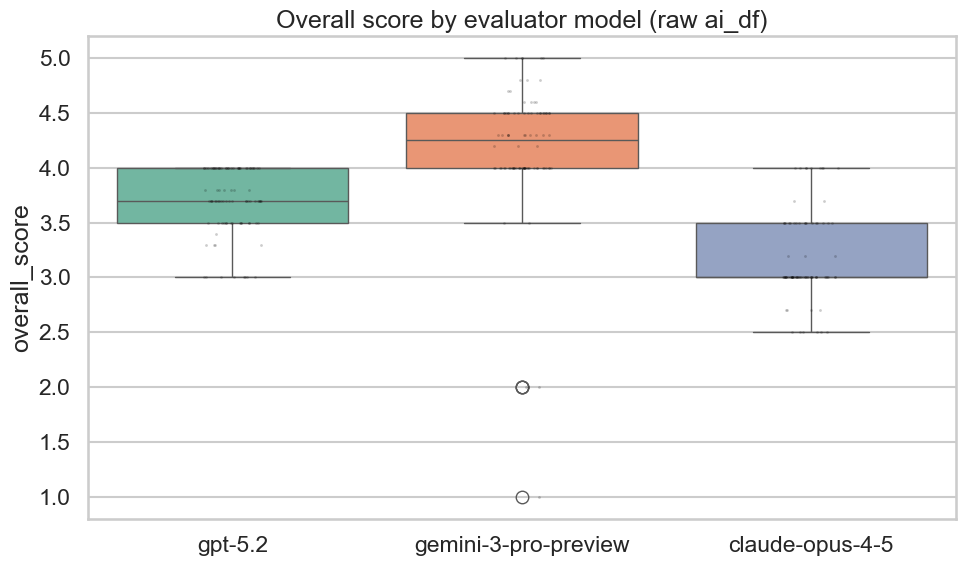

{'kruskal_stat': np.float64(151.14419797112637), 'p_value': np.float64(1.5116610558863968e-33)}


In [30]:
# Purpose:
# Evaluate evaluator distribution differences visually and formally (Kruskal-Wallis).

plt.figure(figsize=(10, 6))
sns.boxplot(data=ai_df, x='evaluator', y='overall_score', palette='Set2')
sns.stripplot(data=ai_df, x='evaluator', y='overall_score', color='black', alpha=0.2, size=2)
plt.title('Overall score by evaluator model (raw ai_df)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_overall_by_evaluator_clean.png', dpi=200, bbox_inches='tight')
plt.show()

parts = [ai_df.loc[ai_df['evaluator'] == e, 'overall_score'].dropna().values for e in sorted(ai_df['evaluator'].dropna().unique())]
kw_stat, kw_p = kruskal(*parts)
print({'kruskal_stat': kw_stat, 'p_value': kw_p})


### Interpretation: Evaluator Difference Test

- Kruskal-Wallis `p_value < 0.05` indicates at least one evaluator distribution differs.
- This supports modeling evaluator effects explicitly (Sections 14 and 18).


## 14) AI self-preference tests (overall + criterion-level + proposal controls)

**Purpose**
Test whether AI evaluators prefer proposals generated by their own model.

**How this is done**
1. Compare self vs non-self scores at proposal level (overall).
2. Repeat by criterion to localize bias.
3. Fit fixed-effects regression with proposal controls to isolate self-preference net of proposal difficulty.

**Why this method is appropriate**
Self-preference is a known LLM evaluator bias; combining non-parametric and controlled regression analyses strengthens causal interpretability.


In [31]:
# Purpose:
# Overall self-preference test by evaluator model at proposal level.

ai_authors = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

sp = ai_df[ai_df['author'].isin(ai_authors) & ai_df['evaluator'].isin(ai_authors)].copy()
sp_prop = (
    sp.groupby(['evaluator', 'author', 'proposal_id'])[QUALITY_METRICS]
    .mean()
    .reset_index()
)
sp_prop['is_self'] = sp_prop['author'] == sp_prop['evaluator']

self_pref_rows = []
for evaluator in ai_authors:
    sub = sp_prop[sp_prop['evaluator'] == evaluator]
    own = sub[sub['is_self']]['overall_score'].dropna()
    other = sub[~sub['is_self']]['overall_score'].dropna()
    out = mannwhitney_summary(own, other, metric_name='overall_score')
    out['evaluator'] = evaluator
    out['mean_self'] = own.mean() if len(own) else np.nan
    out['mean_other'] = other.mean() if len(other) else np.nan
    self_pref_rows.append(out)

self_pref_df = pd.DataFrame(self_pref_rows)
self_pref_df = add_bh_fdr(self_pref_df, p_col='p_value')
self_pref_df


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,evaluator,mean_self,mean_other,q_value
0,overall_score,22,42,215.0,0.000115,-0.534632,large,claude-opus-4-5,2.886364,3.285714,0.000173
1,overall_score,23,46,683.0,0.043942,0.291115,small,gemini-3-pro-preview,4.300000,4.050000,0.043942
2,overall_score,23,46,865.0,0.000008,0.635161,large,gpt-5.2,3.921739,3.600000,0.000024


### Interpretation: Overall Self-Preference

- Compare `mean_self` vs `mean_other` per evaluator.
- `q_value < 0.05` with higher `mean_self` suggests self-favoring bias.
- Opposite direction suggests self-penalization or cross-model preference.


In [32]:
# Purpose:
# Criterion-level self-preference decomposition to identify where bias concentrates.

sp_long = sp_prop.melt(
    id_vars=['evaluator', 'author', 'proposal_id', 'is_self'],
    value_vars=QUALITY_METRICS,
    var_name='metric',
    value_name='score',
).dropna(subset=['score'])

rows = []
for evaluator in ai_authors:
    sube = sp_long[sp_long['evaluator'] == evaluator]
    for metric in QUALITY_METRICS:
        sm = sube[sube['metric'] == metric]
        own = sm[sm['is_self']]['score']
        other = sm[~sm['is_self']]['score']
        out = mannwhitney_summary(own, other, metric_name=metric)
        out['evaluator'] = evaluator
        out['mean_self'] = own.mean() if len(own) else np.nan
        out['mean_other'] = other.mean() if len(other) else np.nan
        rows.append(out)

self_pref_metric_df = pd.DataFrame(rows)
self_pref_metric_df = add_bh_fdr(self_pref_metric_df, p_col='p_value', group_cols=['evaluator'])
self_pref_metric_df.head(20)


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,evaluator,mean_self,mean_other,q_value
0,overall_score,22,42,215.0,0.000115,-0.534632,large,claude-opus-4-5,2.886364,3.285714,0.000404
1,new_question_topic_or_framing,22,42,297.0,0.001531,-0.357143,medium,claude-opus-4-5,3.000000,3.357143,0.002679
2,new_theory_concept_method_dataset_or_design,22,42,247.0,0.000493,-0.465368,medium,claude-opus-4-5,2.545455,3.119048,0.001151
3,unusual_combination_of_existing_ideas,22,42,305.0,0.004271,-0.339827,medium,claude-opus-4-5,3.727273,4.119048,0.005980
4,beyond_state_of_the_art,22,42,366.0,0.098273,-0.207792,small,claude-opus-4-5,2.772727,3.023810,0.098273
5,credible_high_risk_high_gain,22,42,260.0,0.000014,-0.437229,medium,claude-opus-4-5,2.590909,3.047619,0.000097
6,unique_knowledge_generation,22,42,293.0,0.005368,-0.365801,medium,claude-opus-4-5,3.181818,3.547619,0.006263
7,overall_score,23,46,683.0,0.043942,0.291115,small,gemini-3-pro-preview,4.300000,4.050000,0.307594
8,new_question_topic_or_framing,23,46,614.0,0.223465,0.160681,small,gemini-3-pro-preview,4.000000,3.804348,0.391064
9,new_theory_concept_method_dataset_or_design,23,46,612.0,0.202604,0.156900,small,gemini-3-pro-preview,4.043478,3.804348,0.391064


### Interpretation: Criterion-Level Self-Preference

- Identify which criteria show strongest self-preference (`q_value` + large |delta|).
- A bias concentrated in specific criteria is more actionable than uniform global bias.


## 14b) Self-preference visualization


/var/folders/v9/9n8npksj53380_v63d_r9jm80000gn/T/ipykernel_47768/194414371.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
/var/folders/v9/9n8npksj53380_v63d_r9jm80000gn/T/ipykernel_47768/194414371.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
/var/folders/v9/9n8npksj53380_v63d_r9jm80000gn/T/ipykernel_47768/194414371.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_s

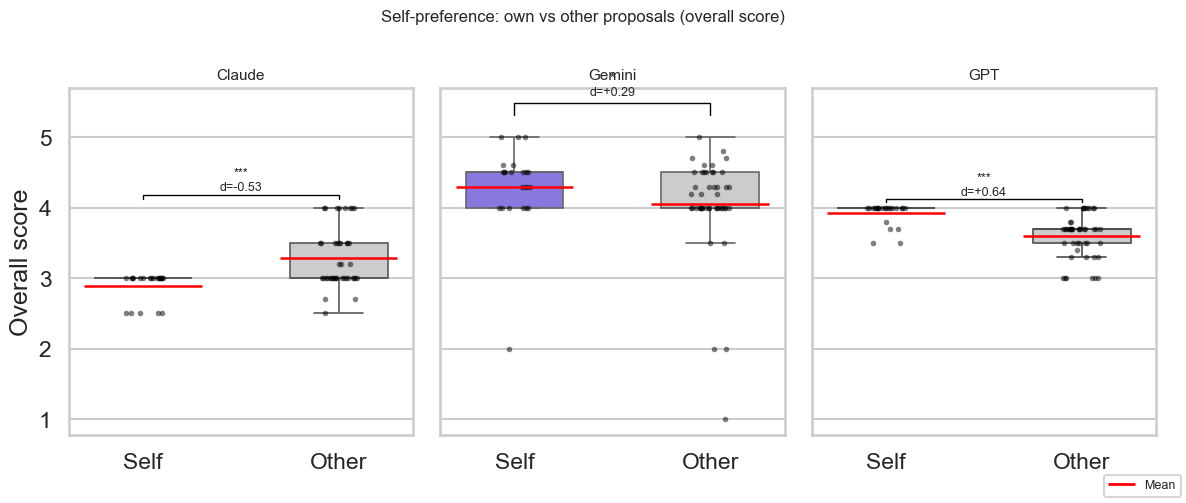

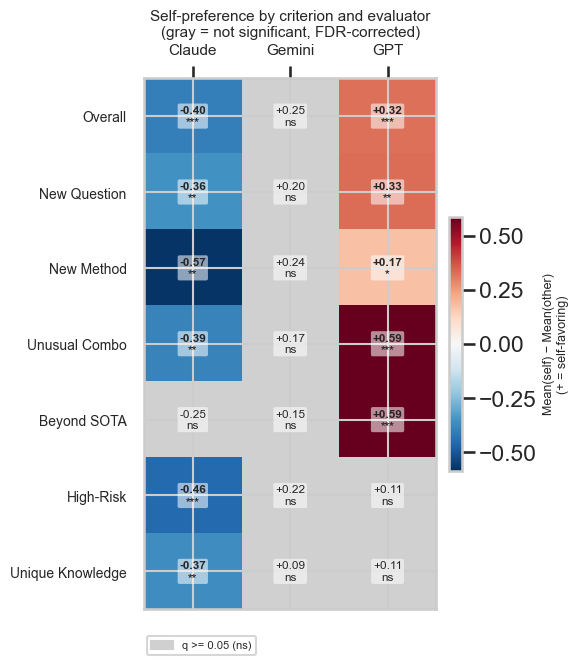

In [33]:
# Two-panel self-preference visualization:
#
# Panel 1 — Faceted strip + box plot (overall score)
#   One column per evaluator model; two groups: self vs other
#   Shows full distribution + mean, annotated with significance
#
# Panel 2 — Criterion-level delta heatmap
#   rows = criteria, columns = evaluator model
#   color = mean_self - mean_other (+ = self-favoring)
#   gray = not significant (q >= 0.05)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
ai_authors_ordered = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# --- Panel 1: Faceted strip + box plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
fig.suptitle('Self-preference: own vs other proposals (overall score)', fontsize=12)

for ax, evaluator in zip(axes, ai_authors_ordered):
    sub = sp_prop[sp_prop['evaluator'] == evaluator][['is_self', 'overall_score']].dropna()
    sub = sub.copy()
    sub['Group'] = sub['is_self'].map({True: 'Self', False: 'Other'})

    grp_color = colors.get(evaluator, '#999999')
    palette = {'Self': grp_color, 'Other': '#cccccc'}

    sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
                palette=palette, width=0.5, linewidth=1.2,
                flierprops=dict(marker=''), ax=ax)
    sns.stripplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)

    # Means as horizontal lines
    for xi, grp in enumerate(['Self', 'Other']):
        m = sub[sub['Group'] == grp]['overall_score'].mean()
        ax.hlines(m, xi - 0.3, xi + 0.3, color='red', linewidth=1.8, zorder=5)

    # Significance annotation
    row = self_pref_df[self_pref_df['evaluator'] == evaluator].iloc[0]
    q   = row.get('q_value', row.get('p_value', 1.0))
    sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
    d   = row['cliffs_delta']
    ymax = sub['overall_score'].max()
    yrange = sub['overall_score'].max() - sub['overall_score'].min()
    y_bracket = ymax + yrange * 0.08
    ax.plot([0, 0, 1, 1], [y_bracket, y_bracket + yrange*0.04,
                            y_bracket + yrange*0.04, y_bracket],
            color='black', linewidth=1)
    ax.text(0.5, y_bracket + yrange * 0.06, f'{sig}\nd={d:+.2f}',
            ha='center', va='bottom', fontsize=9)

    ax.set_title(ai_name_map[evaluator], fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Overall score' if ax == axes[0] else '')

red_line = plt.Line2D([0], [0], color='red', linewidth=2, label='Mean')
fig.legend(handles=[red_line], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'self_pref_strip_overall.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Panel 2: Criterion-level delta heatmap ---
sp_metric = self_pref_metric_df.copy()
sp_metric['delta'] = sp_metric['mean_self'] - sp_metric['mean_other']
sp_metric['evaluator_label'] = sp_metric['evaluator'].map(ai_name_map)

crit_row_order = ['overall_score'] + CRITERIA_ORDER
crit_labels = {
    'overall_score':                               'Overall',
    'new_question_topic_or_framing':               'New Question',
    'new_theory_concept_method_dataset_or_design': 'New Method',
    'unusual_combination_of_existing_ideas':       'Unusual Combo',
    'beyond_state_of_the_art':                     'Beyond SOTA',
    'credible_high_risk_high_gain':                'High-Risk',
    'unique_knowledge_generation':                 'Unique Knowledge',
}
col_labels = [ai_name_map[e] for e in ai_authors_ordered]

delta_grid = sp_metric.pivot(index='metric', columns='evaluator_label', values='delta')\
                       .reindex(index=crit_row_order, columns=col_labels)
q_grid     = sp_metric.pivot(index='metric', columns='evaluator_label', values='q_value')\
                       .reindex(index=crit_row_order, columns=col_labels)

delta_arr = delta_grid.values.astype(float)
q_arr     = q_grid.values.astype(float)

abs_max = np.nanmax(np.abs(delta_arr))
cmap_sp = plt.cm.RdBu_r.copy()   # red = self-favoring (+), blue = other-favoring (-)
cmap_sp.set_bad(color='#d0d0d0')
norm_sp = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
masked  = np.where(q_arr >= 0.05, np.nan, delta_arr)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(masked, cmap=cmap_sp, norm=norm_sp, aspect='auto', interpolation='nearest')

readable_rows = [crit_labels.get(m, m) for m in crit_row_order]
for ri in range(len(crit_row_order)):
    for ci in range(len(col_labels)):
        d = delta_arr[ri, ci]
        q = q_arr[ri, ci]
        if np.isnan(d):
            continue
        sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
        ax.text(ci, ri, f'{d:+.2f}\n{sig}', ha='center', va='center', fontsize=8.5,
                fontweight='bold' if q < 0.05 else 'normal',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.55, edgecolor='none'))

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=6)
ax.set_yticks(range(len(readable_rows)))
ax.set_yticklabels(readable_rows, fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('Mean(self) − Mean(other)\n(+ = self-favoring)', fontsize=9)

gray_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (ns)')
ax.legend(handles=[gray_patch], loc='upper left', bbox_to_anchor=(-0.01, -0.04), fontsize=8)
ax.set_title('Self-preference by criterion and evaluator\n(gray = not significant, FDR-corrected)',
             fontsize=11, pad=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'self_pref_criterion_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


#### Do these models rate their own proosals better? How to remove that bias?

The three models go in opposite directions: Claude self-deprecates, GPT strongly self-inflates, Gemini is neutral. This asymmetry is substantively important — it means GPT cannot be treated as an unbiased evaluator of AI-generated proposals in this experiment.

**What the fixed-effects regression does**
The Mann-Whitney test already shows that self-preference exists, but it doesn't rule out a confound: maybe GPT's own proposals just happen to be better, and that's why GPT scores them higher — not because of bias.

The regression controls for this by including proposal fixed effects (C(proposal_uid)):
`score ~ is_self_num * C(metric) + C(evaluator) + C(author) + C(proposal_uid)`
* C(proposal_uid) — gives each proposal its own intercept, absorbing all proposal-specific quality variation. After this, is_self_num only captures the evaluator's behavior change when reviewing their own work, not proposal quality differences.
* C(evaluator) — absorbs evaluator-level severity/leniency (some models score everything higher).
* `is_self_num * C(metric)` — tests whether self-preference concentrates in specific criteria.
* HC3 — heteroscedasticity-robust standard errors, appropriate when residual variance isn't constant.

The coefficient on is_self_num from this model is the net self-preference effect after removing proposal quality as an explanation. If it's still significant here, the bias interpretation is much stronger than what Mann-Whitney alone can support.

One caveat: the model estimates a single average is_self_num effect across all three evaluators. To get model-specific net effects (like the Mann-Whitney table shows), you'd need to add is_self_num * C(evaluator) as an interaction term.


In [34]:
# Purpose:
# Fixed-effects regression to isolate self-preference net of proposal effects.

try:
    import statsmodels.formula.api as smf

    fe_df = sp_long.copy()
    fe_df['proposal_uid'] = fe_df['author'].astype(str) + '::' + fe_df['proposal_id'].astype(str)
    fe_df['is_self_num'] = fe_df['is_self'].astype(int)

    model_self = smf.ols(
        'score ~ is_self_num * C(metric) + C(evaluator) + C(author) + C(proposal_uid)',
        data=fe_df
    ).fit(cov_type='HC3')

    print(model_self.summary().tables[1])
except Exception as e:
    print('statsmodels model skipped:', e)


                                                                                                                                                                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                                                                                                    2.5872      0.133     19.524      0.000       2.327       2.847
C(metric)[T.credible_high_risk_high_gain]                                                                                                                                                        

/Users/eveyhuang/Documents/NICO/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 83
  warnings.warn('covariance of constraints does not have full '


### Interpretation: Fixed-Effects Self-Preference Model

- Focus on coefficient for `is_self_num` and interactions with `C(metric)`: 
    - After controlling for proposal quality (via C(proposal_uid)) and evaluator severity (C(evaluator)), an evaluator gives their own proposals +0.33 points more on average than they give other models' proposals. The reference metric here is new_question_topic_or_framing (it's what's omitted from the dummies), so 0.33 is the self-preference specifically on that criterion.
    - Self-preference pattern across novelty dimensions can be read from the interaction terms.
- C(evaluator) — overall severity differences
    These are evaluator-level scoring tendencies applied to all proposals, not related to self-preference:
    Gemini scores everything +0.40 higher than Claude (baseline evaluator)
    GPT scores everything −0.20 lower than Claude
    This reflects general leniency/harshness, independent of whose proposal is being evaluated.
- Significant positive terms imply self-preference persists after controlling proposal-level difficulty.
- Non-significant terms suggest observed self-preference may be explained by proposal composition.

**What this adds over the Mann-Whitney results**

The Mann-Whitney showed that GPT self-inflates (+0.99 δ), Claude self-deflates (−0.58 δ), and Gemini is neutral. The regression confirms there is a net positive self-preference (+0.33) after removing the possibility that GPT's own proposals just happen to be better — the proposal fixed effects rule that out. It also decomposes where the bias lives across criteria.
The one limitation: because is_self_num * C(evaluator) isn't in the model, the regression gives you only the average net effect across all three models, not model-specific net effects. The Mann-Whitney table is still the right place to read the per-model story.

## 14c) Fixed-effects regression: forest plot


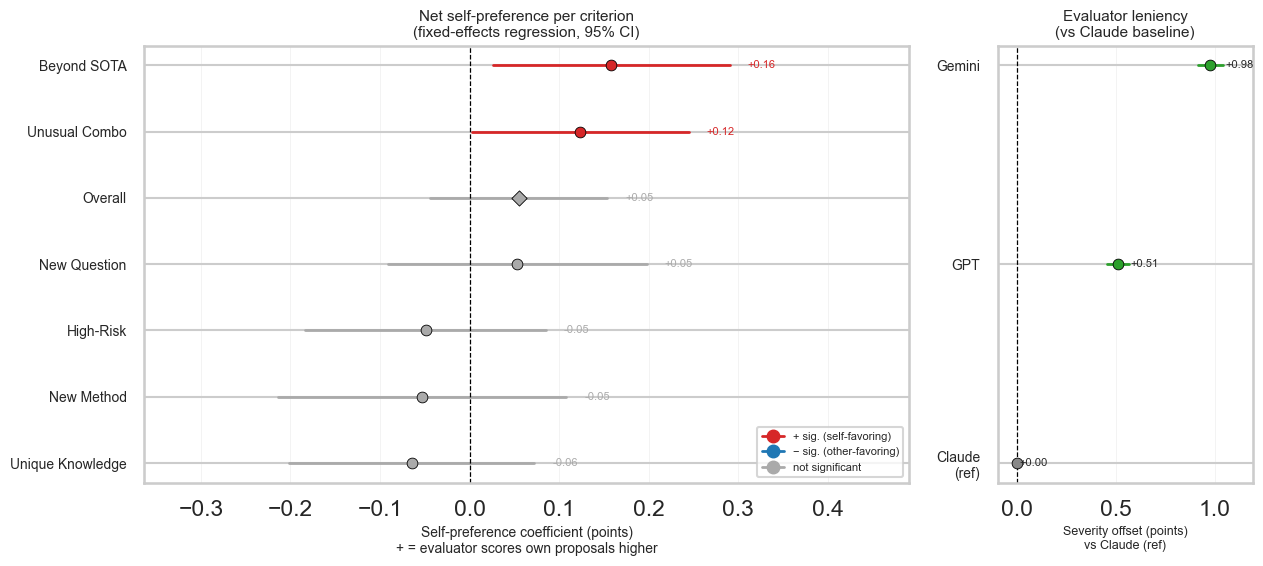

In [35]:
# Forest plot of per-criterion self-preference from the fixed-effects regression.
#
# For each criterion c, the net self-preference is:
#   beta_c = is_self_num + is_self_num:C(metric)[T.c]   (Data_ID is the reference, so beta = is_self_num)
#
# 95% CI uses the model covariance matrix so the uncertainty from both terms is combined correctly:
#   var(beta_c) = var(main) + var(interaction_c) + 2*cov(main, interaction_c)
#
# Separate small panel shows evaluator severity offsets (C(evaluator) main effects).

try:
    import scipy.stats as stats

    crit_labels_reg = {
        'new_question_topic_or_framing':               'New Question',
        'new_theory_concept_method_dataset_or_design': 'New Method',
        'unusual_combination_of_existing_ideas':       'Unusual Combo',
        'beyond_state_of_the_art':                     'Beyond SOTA',
        'credible_high_risk_high_gain':                'High-Risk',
        'unique_knowledge_generation':                 'Unique Knowledge',
        'overall_score':                               'Overall',
    }

    params = model_self.params
    cov    = model_self.cov_params()
    alpha  = 0.05
    z_crit = stats.norm.ppf(1 - alpha / 2)

    main_key = 'is_self_num'
    beta_main = params[main_key]
    var_main  = cov.loc[main_key, main_key]

    # All metrics: new_question_topic_or_framing is reference (interaction absent), others have an interaction term
    all_metrics = ['new_question_topic_or_framing'] + [
        m for m in CRITERIA_ORDER if m != 'new_question_topic_or_framing'
    ] + ['overall_score']

    rows_fe = []
    for metric in all_metrics:
        int_key = f'is_self_num:C(metric)[T.{metric}]'
        if int_key in params.index:
            beta_int = params[int_key]
            var_int  = cov.loc[int_key, int_key]
            cov_mi   = cov.loc[main_key, int_key]
            beta = beta_main + beta_int
            se   = (var_main + var_int + 2 * cov_mi) ** 0.5
        else:  # new_question_topic_or_framing: reference, no interaction term
            beta = beta_main
            se   = var_main ** 0.5
        ci_lo = beta - z_crit * se
        ci_hi = beta + z_crit * se
        sig   = (ci_lo > 0) or (ci_hi < 0)
        rows_fe.append({'metric': metric, 'label': crit_labels_reg[metric],
                         'beta': beta, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'sig': sig})

    fe_df_plot = pd.DataFrame(rows_fe).sort_values('beta', ascending=True).reset_index(drop=True)

    # Evaluator severity offsets (C(evaluator) main effects)
    ev_keys = [k for k in params.index if k.startswith('C(evaluator)')]
    ev_rows = []
    for k in ev_keys:
        name = k.split('[T.')[1].rstrip(']')
        ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
        label = ai_name_map.get(name, name)
        b  = params[k]
        se = cov.loc[k, k] ** 0.5
        ev_rows.append({'label': label, 'beta': b,
                         'ci_lo': b - z_crit * se, 'ci_hi': b + z_crit * se})
    # Add Claude as reference (0)
    ev_rows.append({'label': 'Claude\n(ref)', 'beta': 0, 'ci_lo': 0, 'ci_hi': 0})
    ev_df_plot = pd.DataFrame(ev_rows).sort_values('beta').reset_index(drop=True)

    # --- Figure: two-panel layout ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6),
                                    gridspec_kw={'width_ratios': [3, 1]})

    # Panel 1: Per-criterion self-preference forest plot
    for yi, row in fe_df_plot.iterrows():
        col  = '#d62728' if row['sig'] and row['beta'] > 0 else \
               '#1f77b4' if row['sig'] and row['beta'] < 0 else '#aaaaaa'
        ax1.plot([row['ci_lo'], row['ci_hi']], [yi, yi], color=col, linewidth=2, zorder=2)
        marker = 'D' if row['label'] == 'Overall' else 'o'
        ax1.scatter(row['beta'], yi, color=col, s=60, zorder=3,
                    edgecolors='black', linewidths=0.6, marker=marker)
        ax1.text(row['ci_hi'] + 0.02, yi, f"{row['beta']:+.2f}",
                 va='center', fontsize=8, color=col)

    ax1.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax1.set_yticks(range(len(fe_df_plot)))
    ax1.set_yticklabels(fe_df_plot['label'], fontsize=10)
    ax1.set_xlabel("Self-preference coefficient (points)\n+ = evaluator scores own proposals higher",
                   fontsize=10)
    ax1.set_title("Net self-preference per criterion\n(fixed-effects regression, 95% CI)", fontsize=11)
    ax1.grid(axis='x', linewidth=0.4, alpha=0.4)
    ax1.set_xlim(fe_df_plot['ci_lo'].min() - 0.15, fe_df_plot['ci_hi'].max() + 0.2)

    from matplotlib.lines import Line2D
    legend_h = [
        Line2D([0],[0], color='#d62728', linewidth=2, marker='o', label='+ sig. (self-favoring)'),
        Line2D([0],[0], color='#1f77b4', linewidth=2, marker='o', label='− sig. (other-favoring)'),
        Line2D([0],[0], color='#aaaaaa', linewidth=2, marker='o', label='not significant'),
    ]
    ax1.legend(handles=legend_h, fontsize=8, loc='lower right')

    # Panel 2: Evaluator severity
    for yi, row in ev_df_plot.iterrows():
        is_ref = row['ci_lo'] == row['ci_hi']
        col = '#888888' if is_ref else '#2ca02c'
        if not is_ref:
            ax2.plot([row['ci_lo'], row['ci_hi']], [yi, yi], color=col, linewidth=2, zorder=2)
        ax2.scatter(row['beta'], yi, color=col, s=60, zorder=3,
                    edgecolors='black', linewidths=0.6)
        ax2.text(row['ci_hi'] + 0.01, yi, f"{row['beta']:+.2f}",
                 va='center', fontsize=8)

    ax2.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax2.set_yticks(range(len(ev_df_plot)))
    ax2.set_yticklabels(ev_df_plot['label'], fontsize=10)
    ax2.set_xlabel('Severity offset (points)\nvs Claude (ref)', fontsize=9)
    ax2.set_title('Evaluator leniency\n(vs Claude baseline)', fontsize=11)
    ax2.grid(axis='x', linewidth=0.4, alpha=0.4)
    ax2.set_xlim(ev_df_plot['ci_lo'].min() - 0.1, ev_df_plot['ci_hi'].max() + 0.15)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'self_pref_regression_forest.png', dpi=200, bbox_inches='tight')
    plt.show()

except NameError:
    print('model_self not available — run the regression cell first.')
except Exception as e:
    print(f'Plot failed: {e}')


## 19) R2 Re-Run Without Self-Evaluator Scores on AI-Authored Proposals

This section reruns the same R2 analyses (Sections 10-12 and the same graph types), with one bias-control rule:
- For AI-authored proposals, remove the score where `evaluator == author`.
- AI proposals are then averaged over the 2 cross-evaluators only.
- Human proposals keep all 3 AI evaluators.


In [36]:
# Purpose:
# Reusable R2 pipeline (Sections 10-12 equivalent):
# - proposal-level summary + hist/box/radar plots
# - pairwise tests with FDR + effect-size visualizations
# - robust bootstrap/permutation sensitivity checks
#
# This function writes scenario-specific outputs by suffixing filenames with `run_tag`.

def run_r2_10_12_pipeline(reviews_df, run_tag, run_label):
    import matplotlib.patches as mpatches
    import matplotlib.colors as mcolors

    local_df = reviews_df.copy()
    local_df['proposal_uid'] = local_df['author'].astype(str) + '::' + local_df['proposal_id'].astype(str)

    quality_metrics = ['overall_score'] + CRITERIA_ORDER
    base_groups = ['human-y1', 'human-y2', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    ai_groups = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    keep_groups = ['human-y1', 'human-y2', 'human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

    proposal_scores_local = (
        local_df.groupby(['author', 'proposal_id', 'proposal_uid'])[quality_metrics]
        .mean()
        .reset_index()
    )
    proposal_scores_local = proposal_scores_local[proposal_scores_local['author'].isin(base_groups)].copy()

    def get_vals(group_name, metric):
        if group_name == 'human-all':
            return proposal_scores_local[proposal_scores_local['author'].isin(['human-y1', 'human-y2'])][metric].dropna().values
        return proposal_scores_local[proposal_scores_local['author'] == group_name][metric].dropna().values

    # ---- Section 10 equivalent: summary + plots ----
    summary_rows = []
    for g in keep_groups:
        vals = get_vals(g, 'overall_score')
        summary_rows.append({
            'group': g,
            'n_proposals': int(len(vals)),
            'overall_mean': float(np.mean(vals)) if len(vals) else np.nan,
            'overall_median': float(np.median(vals)) if len(vals) else np.nan,
            'overall_std': float(np.std(vals, ddof=1)) if len(vals) > 1 else np.nan,
        })
    summary_overall_local = pd.DataFrame(summary_rows)

    plot_frames = []
    for g in keep_groups:
        if g == 'human-all':
            tmp = proposal_scores_local[proposal_scores_local['author'].isin(['human-y1', 'human-y2'])].copy()
        else:
            tmp = proposal_scores_local[proposal_scores_local['author'] == g].copy()
        tmp['author_group'] = g
        plot_frames.append(tmp)
    plot_df_local = pd.concat(plot_frames, ignore_index=True)

    # Histogram
    plt.figure(figsize=(12, 7))
    for g in keep_groups:
        s = plot_df_local.loc[plot_df_local['author_group'] == g, 'overall_score'].dropna()
        if len(s) == 0:
            continue
        color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
        plt.hist(s, bins=np.arange(1, 5.6, 0.25), alpha=0.35, label=g, color=color, density=True)
    plt.xlabel('Overall score')
    plt.ylabel('Density')
    plt.title(f'Overall proposal-level score distributions ({run_label})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_overall_histograms_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Boxplot
    plt.figure(figsize=(13, 6))
    palette = {g: (colors['Human'] if 'human' in g else colors.get(g, '#999999')) for g in keep_groups}
    sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)
    sns.stripplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, color='black', alpha=0.25, size=3)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Overall score by author group ({run_label})')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_overall_boxplot_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Radar
    radar_groups = ['human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    radar_labels = {
        'new_question_topic_or_framing':               'New Question\n/ Framing',
        'new_theory_concept_method_dataset_or_design': 'New Theory /\nMethod / Dataset',
        'unusual_combination_of_existing_ideas':       'Unusual\nCombination',
        'beyond_state_of_the_art':                     'Beyond State\nof Art',
        'credible_high_risk_high_gain':                'High-Risk /\nHigh-Gain',
        'unique_knowledge_generation':                 'Unique\nKnowledge',
    }
    radar_markers = {
        'human-all': 'o',
        'claude-opus-4-5': 's',
        'gemini-3-pro-preview': 'D',
        'gpt-5.2': '^',
    }

    angles = np.linspace(0, 2 * np.pi, len(CRITERIA_ORDER), endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    plt.figure(figsize=(11, 10))
    ax = plt.subplot(111, polar=True)

    for g in radar_groups:
        vals = np.array([np.mean(get_vals(g, c)) for c in CRITERIA_ORDER], dtype=float)
        vals = np.concatenate([vals, [vals[0]]])
        col = colors['Human'] if 'human' in g else colors.get(g, '#999999')
        ax.plot(angles, vals, linewidth=2.4, label=g, color=col, marker=radar_markers.get(g, 'o'), markersize=6)
        ax.fill(angles, vals, alpha=0.08, color=col)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([radar_labels.get(c, c) for c in CRITERIA_ORDER], fontsize=10)
    ax.set_ylim(1, 5)
    ax.set_title(f'Criterion profiles by author group ({run_label})', pad=22)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_radar_criteria_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # ---- Section 11 equivalent: pairwise tests ----
    cohort_results = []
    for metric in quality_metrics:
        s1 = get_vals('human-y1', metric)
        s2 = get_vals('human-y2', metric)
        out = mannwhitney_summary(s1, s2, metric_name=metric)
        out['group1'] = 'human-y1'
        out['group2'] = 'human-y2'
        out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
        out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
        cohort_results.append(out)

    human_cohort_local = pd.DataFrame(cohort_results)
    human_cohort_local = add_bh_fdr(human_cohort_local, p_col='p_value', group_cols=['metric'])

    vs_ai_results = []
    for metric in quality_metrics:
        s_human = get_vals('human-all', metric)
        for g in ai_groups:
            s_ai = get_vals(g, metric)
            out = mannwhitney_summary(s_human, s_ai, metric_name=metric)
            out['group1'] = 'human-all'
            out['group2'] = g
            out['mean_group1'] = np.mean(s_human) if len(s_human) else np.nan
            out['mean_group2'] = np.mean(s_ai) if len(s_ai) else np.nan
            vs_ai_results.append(out)

    vs_ai_local = pd.DataFrame(vs_ai_results)
    vs_ai_local = add_bh_fdr(vs_ai_local, p_col='p_value', group_cols=['metric'])

    all_pairwise = []
    for metric in quality_metrics:
        for g1, g2 in itertools.combinations(base_groups, 2):
            s1 = get_vals(g1, metric)
            s2 = get_vals(g2, metric)
            out = mannwhitney_summary(s1, s2, metric_name=metric)
            out['group1'] = g1
            out['group2'] = g2
            out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
            out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
            all_pairwise.append(out)

    pairwise_local = pd.DataFrame(all_pairwise)
    pairwise_local = add_bh_fdr(pairwise_local, p_col='p_value', group_cols=['metric'])

    # ---- Section 11b equivalent: effect-size/significance figures ----
    metric_labels = {
        'overall_score':                               'Overall',
        'new_question_topic_or_framing':               'New Question',
        'new_theory_concept_method_dataset_or_design': 'New Method',
        'unusual_combination_of_existing_ideas':       'Unusual Combo',
        'beyond_state_of_the_art':                     'Beyond SOTA',
        'credible_high_risk_high_gain':                'High-Risk',
        'unique_knowledge_generation':                 'Unique Knowledge',
    }

    row_order = ['overall_score'] + CRITERIA_ORDER
    plot_stats = pd.concat([vs_ai_local, human_cohort_local], ignore_index=True)
    plot_stats['col_label'] = plot_stats['group1'] + ' vs ' + plot_stats['group2']

    col_order = [
        'human-all vs claude-opus-4-5',
        'human-all vs gemini-3-pro-preview',
        'human-all vs gpt-5.2',
        'human-y1 vs human-y2',
    ]

    delta_pivot = plot_stats.pivot(index='metric', columns='col_label', values='cliffs_delta').reindex(index=row_order, columns=col_order)
    q_pivot = plot_stats.pivot(index='metric', columns='col_label', values='q_value').reindex(index=row_order, columns=col_order)

    readable_rows = [metric_labels.get(m, m) for m in row_order]
    readable_cols = ['Human vs\nClaude', 'Human vs\nGemini', 'Human vs\nGPT', 'Y1 vs Y2']

    fig, ax = plt.subplots(figsize=(8.2, 7.1))
    delta_arr = delta_pivot.values.astype(float)
    q_arr = q_pivot.values.astype(float)

    cmap_hm = plt.cm.RdBu.copy()
    cmap_hm.set_bad(color='#d0d0d0')
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    masked = np.where(q_arr >= 0.05, np.nan, delta_arr)

    im = ax.imshow(masked, cmap=cmap_hm, norm=norm, aspect='auto', interpolation='nearest')

    for ri in range(delta_arr.shape[0]):
        for ci in range(delta_arr.shape[1]):
            d = delta_arr[ri, ci]
            q = q_arr[ri, ci]
            if np.isnan(d):
                continue
            sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
            ax.text(ci, ri, f'{d:+.2f}\n{sig}', ha='center', va='center', fontsize=9,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.2))

    ax.set_xticks(np.arange(len(readable_cols)))
    ax.set_xticklabels(readable_cols)
    ax.set_yticks(np.arange(len(readable_rows)))
    ax.set_yticklabels(readable_rows)
    ax.set_title(f"Effect Sizes (Cliff's delta) with FDR significance ({run_label})")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Cliff's delta")

    nonsig_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (not significant)')
    ax.legend(handles=[nonsig_patch], loc='upper left', bbox_to_anchor=(0, -0.08), frameon=False)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_effectsize_heatmap_{run_tag}.png', dpi=220, bbox_inches='tight')
    plt.show()

    # Dot plot (human-all vs AI only)
    dot_df = vs_ai_local.copy()
    dot_df = dot_df[dot_df['group1'] == 'human-all'].copy()
    dot_df['metric_label'] = dot_df['metric'].map(metric_labels)
    dot_df['q_plot'] = dot_df['q_value'].clip(lower=1e-12)
    dot_df['dot_size'] = 40 + 45 * (-np.log10(dot_df['q_plot']))
    dot_df['sig'] = dot_df['q_value'] < 0.05

    metric_order = [metric_labels.get(m, m) for m in row_order][::-1]

    plt.figure(figsize=(10.5, 6.8))
    for g in ai_groups:
        sub = dot_df[dot_df['group2'] == g]
        yvals = [metric_order.index(m) for m in sub['metric_label']]
        face = colors.get(g, '#888888')
        plt.scatter(
            sub['cliffs_delta'],
            yvals,
            s=sub['dot_size'],
            c=face,
            edgecolors='black',
            linewidths=0.7,
            alpha=0.88,
            label=g,
            marker='o',
        )
        nonsig = sub[~sub['sig']]
        if len(nonsig) > 0:
            y_ns = [metric_order.index(m) for m in nonsig['metric_label']]
            plt.scatter(
                nonsig['cliffs_delta'],
                y_ns,
                s=nonsig['dot_size'],
                facecolors='none',
                edgecolors='black',
                linewidths=1.1,
                marker='o',
            )

    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.yticks(np.arange(len(metric_order)), metric_order)
    plt.xlabel("Cliff's delta (human-all minus AI model)")
    plt.title(f'Human-vs-AI Effect Sizes by Metric ({run_label})')
    plt.legend(title='AI Model', loc='lower right')
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_effectsize_dotplot_{run_tag}.png', dpi=220, bbox_inches='tight')
    plt.show()

    # ---- Section 12 equivalent: robust checks ----
    robust_rows = []
    for metric in quality_metrics:
        x = get_vals('human-all', metric)
        for g in ai_groups:
            y = get_vals(g, metric)
            mean_diff, ci_lo, ci_hi = bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42)
            p_perm = permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42)
            robust_rows.append({
                'metric': metric,
                'comparison': f'human-all minus {g}',
                'n_human_all': len(x),
                'n_other': len(y),
                'mean_diff': mean_diff,
                'bootstrap_ci_lo': ci_lo,
                'bootstrap_ci_hi': ci_hi,
                'permutation_p_value': p_perm,
            })

    robust_local = pd.DataFrame(robust_rows)
    robust_local = add_bh_fdr(robust_local, p_col='permutation_p_value', group_cols=['metric'], out_col='permutation_q_value')

    # Save scenario-specific tables
    summary_overall_local.to_csv(TABLES_DIR / f'quality_summary_overall_by_author_group_{run_tag}.csv', index=False)
    human_cohort_local.to_csv(TABLES_DIR / f'quality_human_cohort_mw_cliffs_{run_tag}.csv', index=False)
    vs_ai_local.to_csv(TABLES_DIR / f'quality_vs_ai_mw_cliffs_{run_tag}.csv', index=False)
    pairwise_local.to_csv(TABLES_DIR / f'quality_pairwise_mw_cliffs_all_metrics_{run_tag}.csv', index=False)
    robust_local.to_csv(TABLES_DIR / f'quality_robust_bootstrap_permutation_{run_tag}.csv', index=False)

    print(f'[{run_label}] proposal-level N by group:')
    display(summary_overall_local)

    print(f'[{run_label}] human-all vs AI tests (FDR-adjusted):')
    display(vs_ai_local.sort_values(['metric', 'q_value', 'p_value']))

    print(f'[{run_label}] robust sensitivity (head):')
    display(robust_local.head(20))

    return {
        'proposal_scores': proposal_scores_local,
        'summary_overall': summary_overall_local,
        'human_cohort': human_cohort_local,
        'vs_ai': vs_ai_local,
        'pairwise': pairwise_local,
        'robust': robust_local,
        'plot_df': plot_df_local,
    }


Rows removed (AI self-evaluations): 69
Remaining rows: 207
Remaining evaluator counts by author (AI authors should each have 2 evaluators/proposal):


evaluator,claude-opus-4-5,gemini-3-pro-preview,gpt-5.2
author,,,
claude-opus-4-5,0,23,23
gemini-3-pro-preview,23,0,23
gpt-5.2,23,23,0


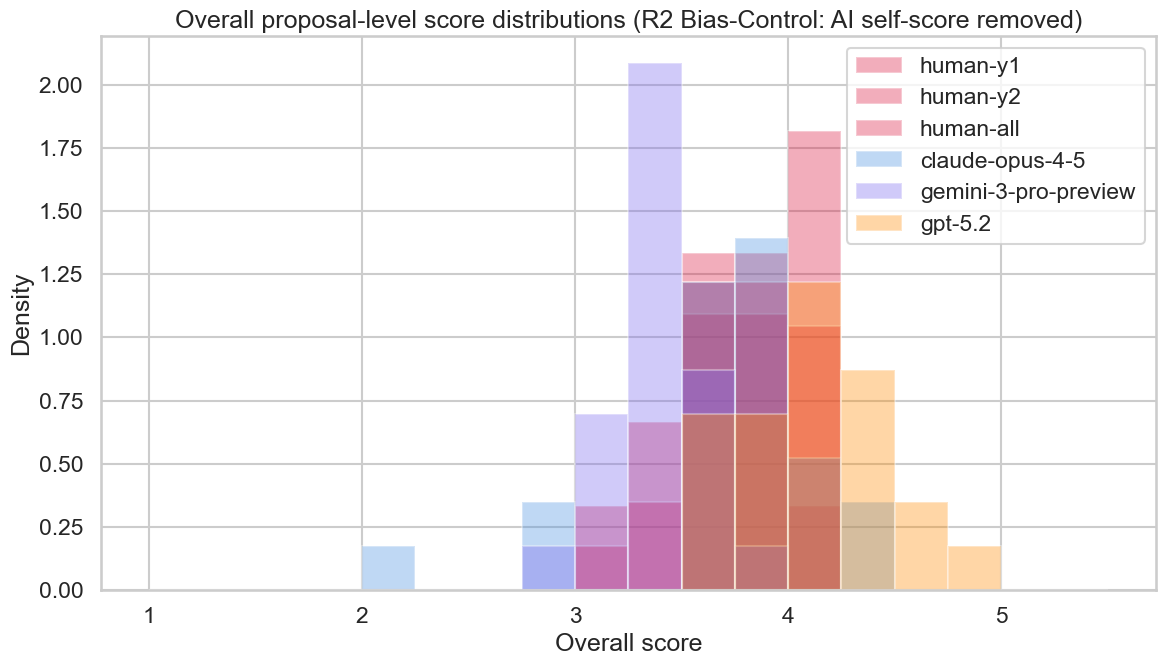

/var/folders/v9/9n8npksj53380_v63d_r9jm80000gn/T/ipykernel_47768/2723384484.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)


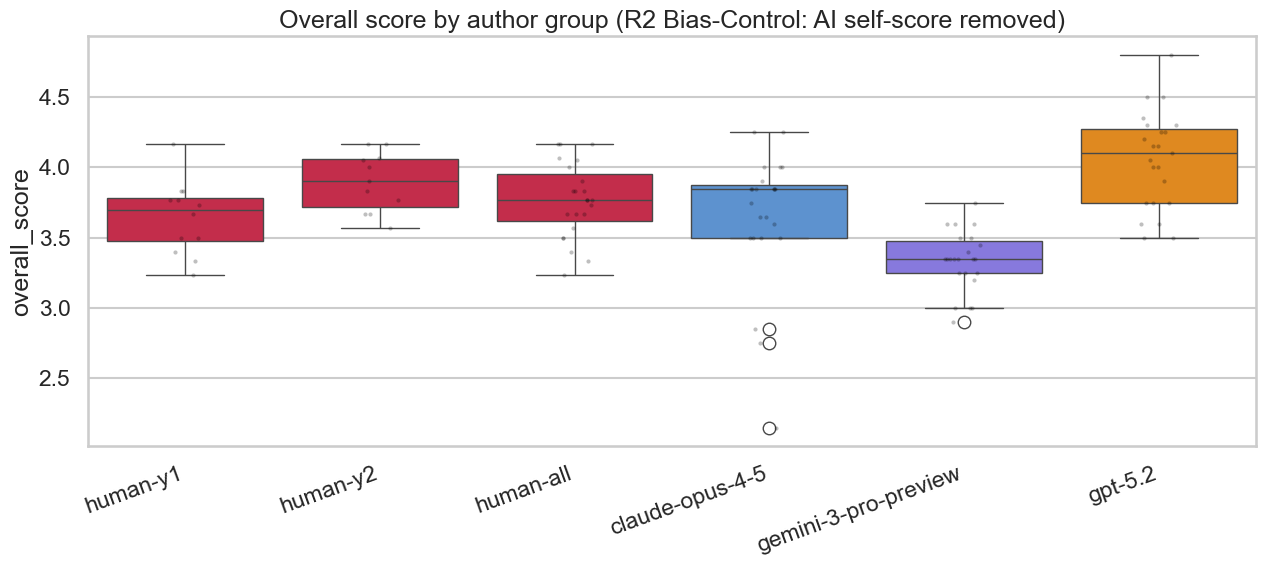

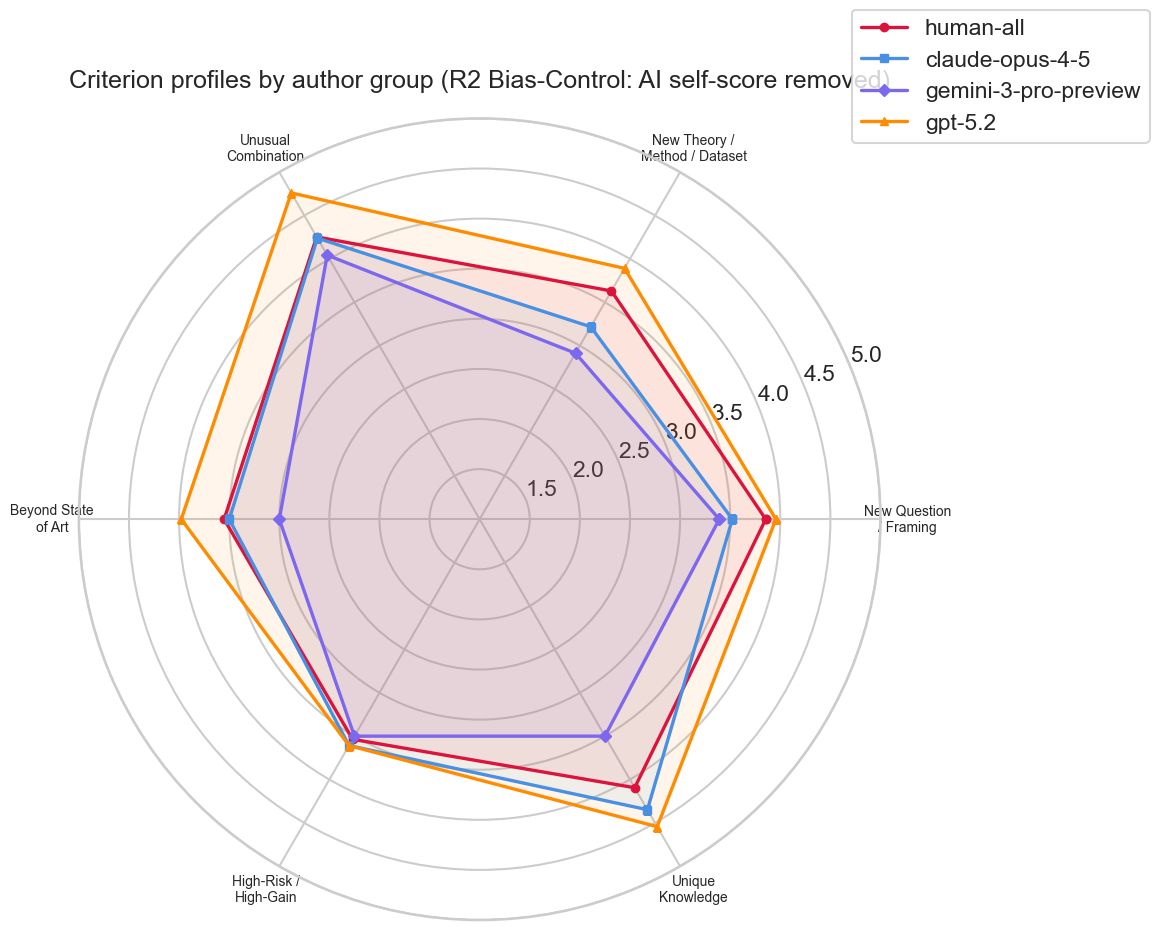

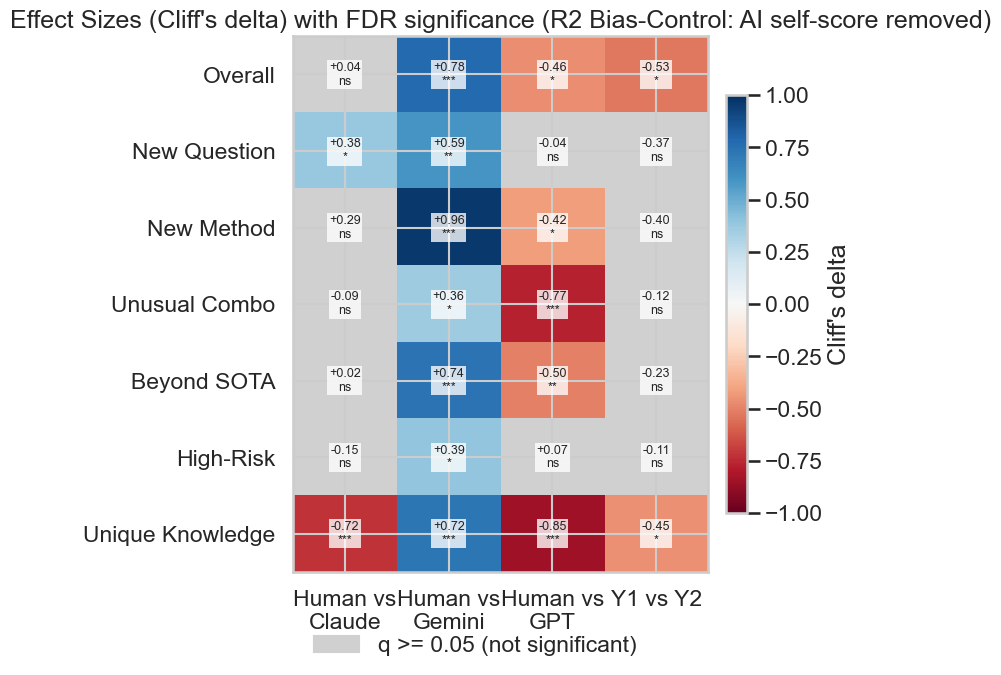

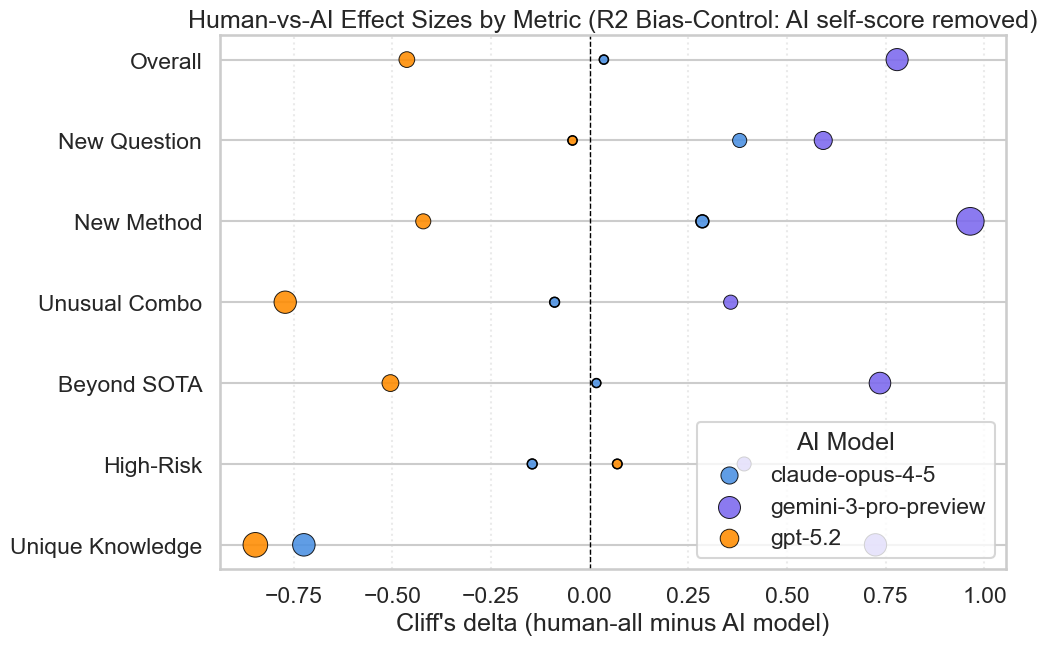

[R2 Bias-Control: AI self-score removed] proposal-level N by group:


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.644444,3.700000,0.261052
1,human-y2,11,3.895455,3.900000,0.210830
2,human-all,23,3.764493,3.766667,0.265922
3,claude-opus-4-5,23,3.647826,3.850000,0.485817
4,gemini-3-pro-preview,23,3.334783,3.350000,0.215552
5,gpt-5.2,23,4.054348,4.100000,0.344737


[R2 Bias-Control: AI self-score removed] human-all vs AI tests (FDR-adjusted):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
13,beyond_state_of_the_art,23,23,459.0,1.093389e-05,0.735350,large,human-all,gemini-3-pro-preview,3.550725,3.000000,3.280167e-05
14,beyond_state_of_the_art,23,23,131.0,2.897890e-03,-0.504726,large,human-all,gpt-5.2,3.550725,3.978261,4.346835e-03
12,beyond_state_of_the_art,23,23,269.0,9.282665e-01,0.017013,negligible,human-all,claude-opus-4-5,3.550725,3.500000,9.282665e-01
16,credible_high_risk_high_gain,23,23,368.0,1.390816e-02,0.391304,medium,human-all,gemini-3-pro-preview,3.536232,3.500000,4.172448e-02
15,credible_high_risk_high_gain,23,23,226.0,3.911851e-01,-0.145558,negligible,human-all,claude-opus-4-5,3.536232,3.608696,5.867777e-01
17,credible_high_risk_high_gain,23,23,283.0,6.807823e-01,0.069943,negligible,human-all,gpt-5.2,3.536232,3.608696,6.807823e-01
4,new_question_topic_or_framing,23,23,421.0,4.490761e-04,0.591682,large,human-all,gemini-3-pro-preview,3.855072,3.391304,1.347228e-03
3,new_question_topic_or_framing,23,23,365.0,2.545418e-02,0.379962,medium,human-all,claude-opus-4-5,3.855072,3.521739,3.818127e-02
5,new_question_topic_or_framing,23,23,253.0,8.046455e-01,-0.043478,negligible,human-all,gpt-5.2,3.855072,3.956522,8.046455e-01
7,new_theory_concept_method_dataset_or_design,23,23,519.5,3.667103e-09,0.964083,large,human-all,gemini-3-pro-preview,3.630435,2.913043,1.100131e-08


[R2 Bias-Control: AI self-score removed] robust sensitivity (head):


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,0.116667,-0.084873,0.347844,0.323935,0.323935
1,overall_score,human-all minus gemini-3-pro-preview,23,23,0.429710,0.292754,0.560888,0.000200,0.000600
2,overall_score,human-all minus gpt-5.2,23,23,-0.289855,-0.463062,-0.115906,0.002799,0.004199
3,new_question_topic_or_framing,human-all minus claude-opus-4-5,23,23,0.333333,0.043478,0.608877,0.041992,0.062987
4,new_question_topic_or_framing,human-all minus gemini-3-pro-preview,23,23,0.463768,0.210145,0.695652,0.001000,0.002999
5,new_question_topic_or_framing,human-all minus gpt-5.2,23,23,-0.101449,-0.398551,0.181159,0.473505,0.473505
6,new_theory_concept_method_dataset_or_design,human-all minus claude-opus-4-5,23,23,0.413043,0.137681,0.702899,0.007199,0.010798
7,new_theory_concept_method_dataset_or_design,human-all minus gemini-3-pro-preview,23,23,0.717391,0.528986,0.905978,0.000200,0.000600
8,new_theory_concept_method_dataset_or_design,human-all minus gpt-5.2,23,23,-0.260870,-0.521739,0.014493,0.070786,0.070786
9,unusual_combination_of_existing_ideas,human-all minus claude-opus-4-5,23,23,0.014493,-0.239130,0.289855,0.950810,0.950810


In [37]:
# Build cross-evaluator-only dataset for AI-authored proposals.
# Rule:
# - AI-authored proposals: drop evaluator==author (remove self-review).
# - Human-authored proposals: keep all 3 AI evaluators.

ai_authors = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

self_mask = ai_df['author'].isin(ai_authors) & (ai_df['evaluator'] == ai_df['author'])
ai_df_cross_eval_only = ai_df.loc[~self_mask].copy()

print('Rows removed (AI self-evaluations):', int(self_mask.sum()))
print('Remaining rows:', len(ai_df_cross_eval_only))
print('Remaining evaluator counts by author (AI authors should each have 2 evaluators/proposal):')
display(
    ai_df_cross_eval_only[ai_df_cross_eval_only['author'].isin(ai_authors)]
    .groupby(['author', 'evaluator'])
    .size()
    .unstack(fill_value=0)
)

r2_cross_eval_results = run_r2_10_12_pipeline(
    reviews_df=ai_df_cross_eval_only,
    run_tag='cross_eval_only',
    run_label='R2 Bias-Control: AI self-score removed',
)


## 20) Export tables

This section writes all analysis artifacts (mapping diagnostics, test tables, robustness outputs, bias/proxy/reliability results) to `results/tables/quality/` for downstream reporting and manuscript integration.


In [38]:
# Purpose:
# Persist all analysis outputs for reporting, reproducibility, and manuscript figures/tables.

# --- R2: Proposal quality by author group ---
summary_overall_df.to_csv(TABLES_DIR / 'novelty_summary_overall_by_author_group.csv', index=False)
pairwise_df.to_csv(TABLES_DIR / 'novelty_pairwise_mw_cliffs_all_metrics_proposal_level.csv', index=False)
human_cohort_df.to_csv(TABLES_DIR / 'novelty_human_cohort_y1_vs_y2.csv', index=False)
vs_ai_df.to_csv(TABLES_DIR / 'novelty_human_vs_ai_mw_cliffs.csv', index=False)
robust_quality_df.to_csv(TABLES_DIR / 'novelty_robust_bootstrap_permutation_key_comparisons.csv', index=False)

# --- R3: Self-preference bias ---
eval_stats.to_csv(TABLES_DIR / 'novelty_evaluator_overall_stats_clean.csv')
self_pref_df.to_csv(TABLES_DIR / 'novelty_self_preference_tests_overall.csv', index=False)
self_pref_metric_df.to_csv(TABLES_DIR / 'novelty_self_preference_tests_by_metric.csv', index=False)

# --- R2 re-run: cross-evaluator only (AI self-scores removed) ---
r2_cross_eval_results['summary_overall'].to_csv(TABLES_DIR / 'novelty_cross_eval_summary_overall.csv', index=False)
r2_cross_eval_results['pairwise'].to_csv(TABLES_DIR / 'novelty_cross_eval_pairwise_mw_cliffs.csv', index=False)
r2_cross_eval_results['robust'].to_csv(TABLES_DIR / 'novelty_cross_eval_robust_bootstrap.csv', index=False)
r2_cross_eval_results['human_cohort'].to_csv(TABLES_DIR / 'novelty_cross_eval_human_cohort.csv', index=False)

print('Saved figures to:', FIGURES_DIR)
for p in sorted(FIGURES_DIR.glob('*.png')):
    print('-', p.name)

print('Saved tables to:', TABLES_DIR)
for p in sorted(TABLES_DIR.glob('novelty_*')):
    print('-', p.name)


Saved figures to: ../results/figures/quality/minimal/novelty
- quality_effect_size_dotplot.png
- quality_effect_size_heatmap.png
- quality_effectsize_dotplot_cross_eval_only.png
- quality_effectsize_heatmap_cross_eval_only.png
- quality_overall_boxplot_proposal_level.png
- quality_overall_boxplot_proposal_level_cross_eval_only.png
- quality_overall_by_evaluator_clean.png
- quality_overall_histograms_proposal_level.png
- quality_overall_histograms_proposal_level_cross_eval_only.png
- quality_radar_criteria_proposal_level.png
- quality_radar_criteria_proposal_level_cross_eval_only.png
- self_pref_criterion_heatmap.png
- self_pref_regression_forest.png
- self_pref_strip_overall.png
Saved tables to: ../results/tables/quality/minimal/novelty
- novelty_cross_eval_human_cohort.csv
- novelty_cross_eval_pairwise_mw_cliffs.csv
- novelty_cross_eval_robust_bootstrap.csv
- novelty_cross_eval_summary_overall.csv
- novelty_evaluator_overall_stats_clean.csv
- novelty_human_cohort_y1_vs_y2.csv
- novelt